<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/EDA_of_OBIS__Copernicus_Human_Sightings_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA of OBIS + Copernicus Human Sightings Dataset



## Step 1 - Importing the Dataset from Github

In [35]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/obis_whaleshark_clean_enriched.csv"
db = pd.read_csv(url, low_memory=False)
db['date'] = pd.to_datetime(db['date'])
db['month'] = db['month'].astype(int)
db['year'] = db['year'].astype(int)
print(db.shape)
db.head()

(9731, 26)


,dataset_id,id,occurrenceID,catalogNumber,institutionCode,datasetName,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters,date,...,bathymetry,shoredistance,sst,sss,flags,is_on_land,uncertainity,sst_cmems,chl_cmems,sss_cmems
0,031dba90-d480-419a-a562-be9a34bc5c49,74b78261-5cb6-4206-9050-8aef7a1a6f16,QLD-Wildnet-6310241,NaN,NaN,NaN,-24.897300,153.272100,100.0,2003-09-09,...,-2.69,59.0,23.89,35.42,[],True,False,21.899993,0.245343,35.634938
1,0820b10a-5710-4e90-b9ed-a2ad7c7ec742,19da48de-f5b6-4941-823f-c5452c2f7077,19978115-release,NaN,IMOS,NaN,-34.960000,118.170000,100.0,2010-07-20,...,-2.00,12.0,19.25,35.58,[],True,False,18.129993,NaN,35.583056
2,31677373-22f8-4688-940b-9921d4595bee,5b085b19-befd-40b9-b3ac-1fee69a9b007,CDF:ECOM:140802:WO04:D:7852:11271,NaN,CDF,Biodiversity of Galápagos Marine Reserv,1.383180,-91.811100,NaN,2002-08-14,...,-1.00,32.0,25.63,33.74,[NO_DEPTH],True,False,23.729993,0.174842,34.659871
3,31677373-22f8-4688-940b-9921d4595bee,924bdbb8-a39a-4917-9acc-9c2cf025a692,CDF:ECOM:140618:WO04:D:7852:40365,NaN,CDF,Biodiversity of Galápagos Marine Reserv,1.383180,-91.811100,NaN,2018-06-14,...,-1.00,32.0,25.63,33.74,[NO_DEPTH],True,False,26.979993,0.133131,33.903012
4,7fad32f7-40f3-4134-84a8-beca24103910,66523c33-23d4-4bf3-b560-136e0d4d5225,NaN,SAMS-SHARKS-011624,SAMS,NaN,-34.345001,21.893299,NaN,1994-02-19,...,-2.00,54.0,18.10,35.47,[NO_DEPTH],True,False,NaN,NaN,35.094760


## Step 2 - Creating the map builder function

Installing library to see the background of the map

In [3]:
!pip install -q global-land-mask

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.1 MB/s eta 0:00:00


In [4]:
import matplotlib.pyplot as plt
from global_land_mask import globe

def map_builder(subset, title, color="#2a78d6", bbox=(-180, 180, -60, 60), step=None):
    lon0, lon1, lat0, lat1 = bbox
    if step is None:
        step = 0.25 if (lon1 - lon0) > 90 else 0.02
    lons = np.arange(lon0, lon1, step); lats = np.arange(lat0, lat1, step)
    lon_g, lat_g = np.meshgrid(lons, lats)
    land = globe.is_land(lat_g, lon_g)

    w = 14; h = max(4, min(14, w * (lat1 - lat0) / (lon1 - lon0)))   # altezza proporzionata
    plt.figure(figsize=(w, h))
    plt.gca().set_aspect('equal')                                      # 1° = 1° in entrambe le direzioni
    plt.contourf(lons, lats, land, levels=[0.5, 1.5], colors=["#d9cfc1"])
    plt.scatter(db['decimalLongitude'], db['decimalLatitude'], s=1, color="#c8c8c8")
    plt.scatter(subset['decimalLongitude'], subset['decimalLatitude'], s=10, color=color, alpha=0.8)
    plt.xlim(lon0, lon1); plt.ylim(lat0, lat1)
    plt.title(f"{title}  (n = {len(subset):,})")
    plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.grid(alpha=0.3)
    plt.show()

## Step 3 - EDA

### 1) Encounters maps

#### **Global Map**

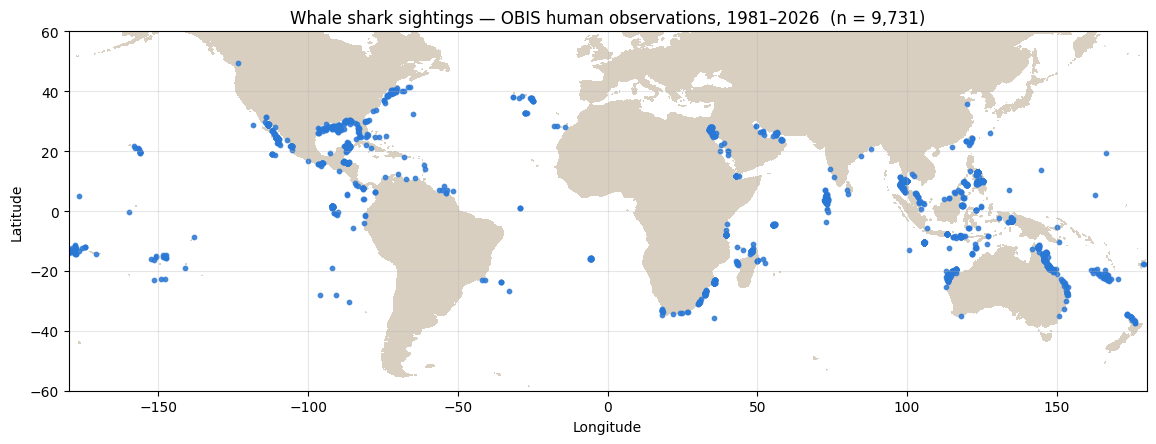

In [5]:
map_builder(db, "Whale shark sightings — OBIS human observations, 1981–2026")

From the global map we can see the distribution of the sightings all around the globe and we can identify the main areas of study for whale sharks:

**Indian Ocean**
1. Ningaloo Reef, Western Australia — the densest cluster in the dataset

2. Mozambique Channel (Tofo) and Tanzania (Mafia Island), with scattered
records along Kenya and Madagascar
3. South Africa, east coast (KwaZulu-Natal down to the Cape)
4. Maldives
5. Seychelles
6. Red Sea (Egypt, Sudan) and Gulf of Aden / Djibouti
7. Arabian Sea (Oman) and Arabian/Persian Gulf (Qatar, UAE)
8. Andaman Sea / Thailand

**Western Pacific**

9. Philippines (Donsol, Oslob, Tubbataha) — second densest cluster

10. Taiwan and southern Japan
11. Indonesia and Papua (Cenderawasih Bay, Triton Bay)
12. Eastern Australia (Great Barrier Reef, Queensland) and New Caledonia
13. Fiji / Tonga and northern New Zealand

**Central Pacific**

14. Hawaii
15. French Polynesia / Society Islands

**Eastern Pacific**

16. Mexican Pacific: Gulf of California (La Paz, Bahía de los Ángeles) and Baja California
17. Galápagos and the Panama / Ecuador coast

**Atlantic**

18. Gulf of Mexico (Yucatán, Texas, Louisiana) and the Caribbean (Belize, Honduras, Cuba)
19. US East Coast and Florida
20. Brazil (Fernando de Noronha, NE coast) and St Helena
21. Azores, Canary Islands and West Africa (Senegal, Cape Verde)

Sightings are almost entirely coastal and tropical-subtropical (roughly between 35°S and 40°N).

#### **Regional Maps**

In [37]:
regions = {
  "Indian Ocean": {
    "Ningaloo Reef (W Australia)":        (112, 116, -25, -20),
    "Mozambique / Tanzania / Kenya":      ( 32,  41, -28,  -1),
    "Madagascar":                         ( 42,  51, -26, -12),
    "South Africa":                       ( 15,  33, -36, -28),
    "Maldives":                           (72, 74.5, -1.5, 7.5),
    "Seychelles":                         ( 52,  58,  -8,  -3),
    "Red Sea / Djibouti":                 ( 32,  45,  10,  30),
    "Oman / Arabian Gulf":                ( 48,  62,  20,  30),
    "Andaman Sea / Thailand":             ( 92, 101,   5,  14),
  },
  "Western Pacific": {
    "Philippines":                        (117, 127,   5,  20),
    "Taiwan / Japan":                     (118, 135,  20,  35),
    "Vietnam / Malaysia / Gulf of Thailand": (100, 112, 0, 15),
    "NW Australia (Kimberley / NT)":      (112, 138, -20, -10),
    "Indonesia / Papua":                  (100, 141, -10,   5),
    "Papua New Guinea / Solomon Is.":     (141, 162, -12,  -2),
    "E Australia / New Caledonia":        (142, 170, -38, -10),
    "New Zealand":                        (165, 180, -42, -30),
    "Fiji / Tonga":                       (-180,-170,-25, -12),
  },
  "Central Pacific": {
    "Hawaii":                             (-161,-154,  18,  23),
    "French Polynesia":                   (-155,-134, -25,  -8),
  },
  "Eastern Pacific": {
    "Mexican Pacific / Gulf of California": (-118,-100, 15, 32),
    "Galápagos / Panama / Ecuador":       ( -95, -75, -10,  10),
  },
  "Atlantic": {
    "Gulf of Mexico / Caribbean":         ( -98, -55,  4,  31),
    "US East Coast / Florida":            ( -82, -65,  24,  45),
    "Brazil / St Helena":                 ( -50,   0, -30,   0),
    "Azores / Canaries / W Africa":       ( -32,  -5,  10,  42),
  },
}

def assign_region(lat, lon):
    for ocean, sites in regions.items():
        for name, (lon0, lon1, lat0, lat1) in sites.items():
            if lon0 <= lon <= lon1 and lat0 <= lat <= lat1:
                return ocean, name
    return "Other", "Other"

db[['ocean', 'site']] = [assign_region(a, b) for a, b in zip(db['decimalLatitude'], db['decimalLongitude'])]
print(db['ocean'].value_counts(), "\n")
print(db['site'].value_counts())



ocean
Indian Ocean       5499
Western Pacific    2526
Atlantic           1078
Eastern Pacific     445
Other               156
Central Pacific      27
Name: count, dtype: int64 

site
Ningaloo Reef (W Australia)              3972
Philippines                              2110
Gulf of Mexico / Caribbean                978
Mozambique / Tanzania / Kenya             962
Mexican Pacific / Gulf of California      341
Maldives                                  200
E Australia / New Caledonia               183
Andaman Sea / Thailand                    167
Other                                     156
Indonesia / Papua                         125
Galápagos / Panama / Ecuador              104
Red Sea / Djibouti                         87
US East Coast / Florida                    56
Madagascar                                 38
NW Australia (Kimberley / NT)              33
Azores / Canaries / W Africa               26
South Africa                               26
Oman / Arabian Gulf                

Records are **very unevenly distributed**. Four sites hold 82% of all sightings: *Ningaloo Reef (3,972), the Philippines (2,110), the Gulf of Mexico / Caribbean (978) and Mozambique / Tanzania / Kenya (971).*

**Six sites have between 100 and 350 records** (Mexican Pacific, Maldives, E Australia, Andaman Sea, Indonesia / Papua, Galápagos / E Pacific).

The **remaining sites** have **fewer than 100 records** each.

**151 records** (1.6%) are scattered single sightings **not assigned to any site**.

This shapes the rest of the analysis: **month-by-month seasonality **can **only be described reliably for the four large sites**; the six **medium sites allow a less precise** (seasonal) comparison; **the small sites are used only to describe presence**.

##### **Indian Ocean**

###### Ningaloo Reef (W Australia)

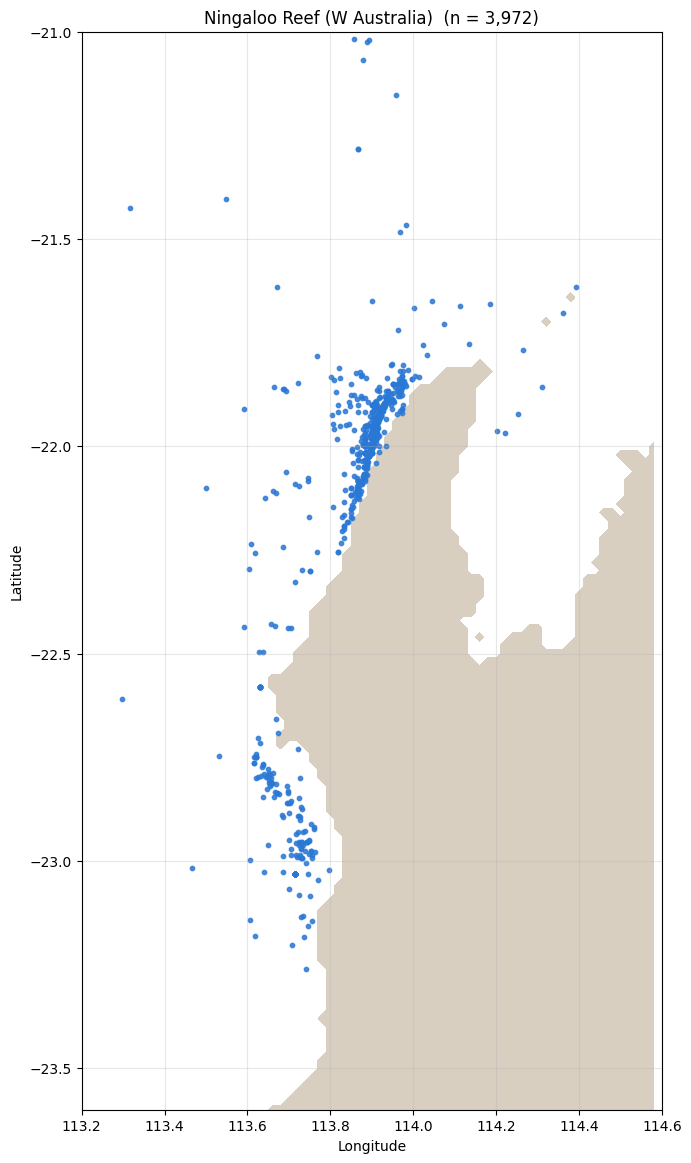

In [7]:
site = "Ningaloo Reef (W Australia)"
map_builder(db[db['site'] == site], site, bbox=(113.2, 114.6, -23.6, -21.0))

2 main areas of concentration inside for this region

###### Mozambique / Tanzania / Kenya

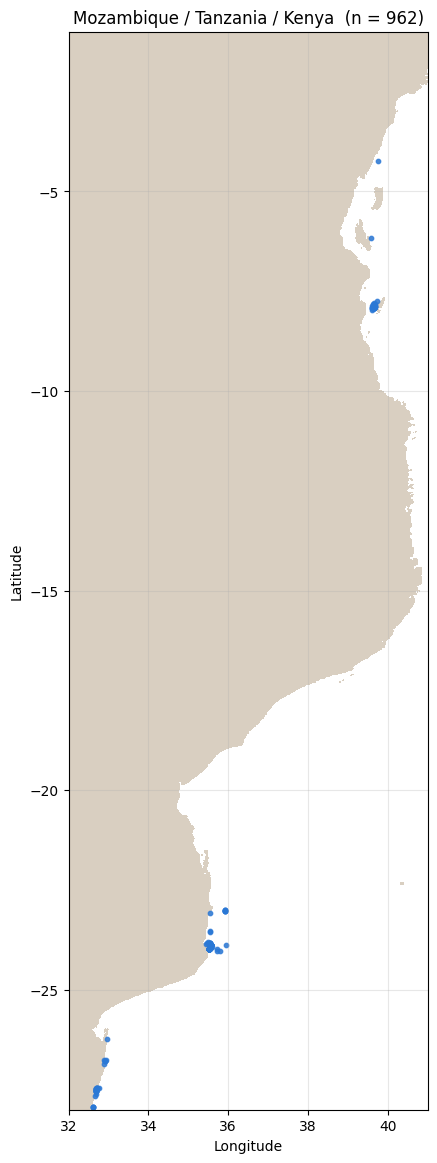

In [8]:
site = "Mozambique / Tanzania / Kenya"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

3 main areas of concentration inside this region

###### Madagascar

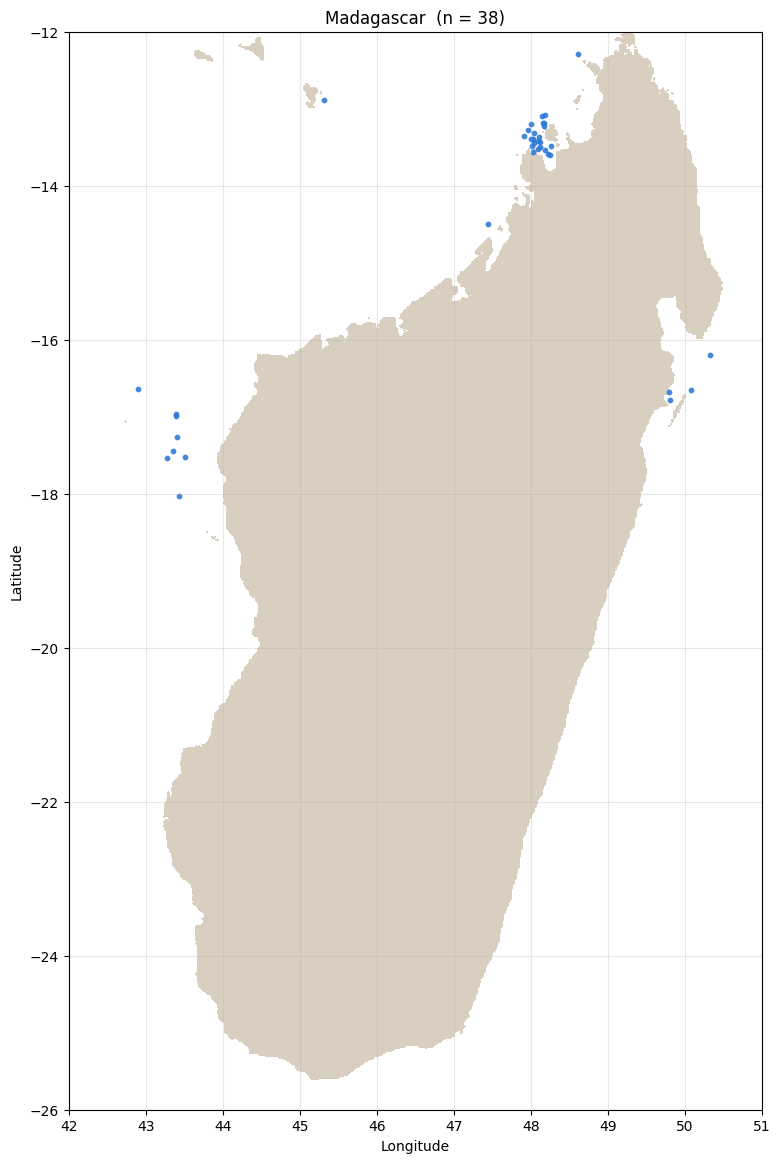

In [9]:
site = "Madagascar"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

Nosy be island main sighting spot

###### South Africa

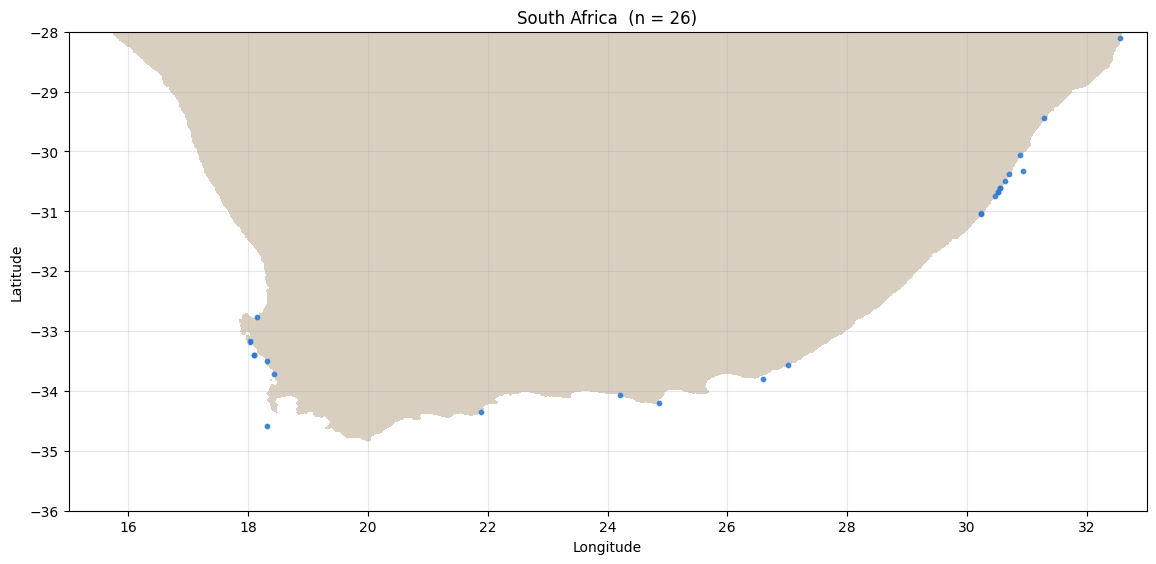

In [10]:
site = "South Africa"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

All around the coast

###### Maldives

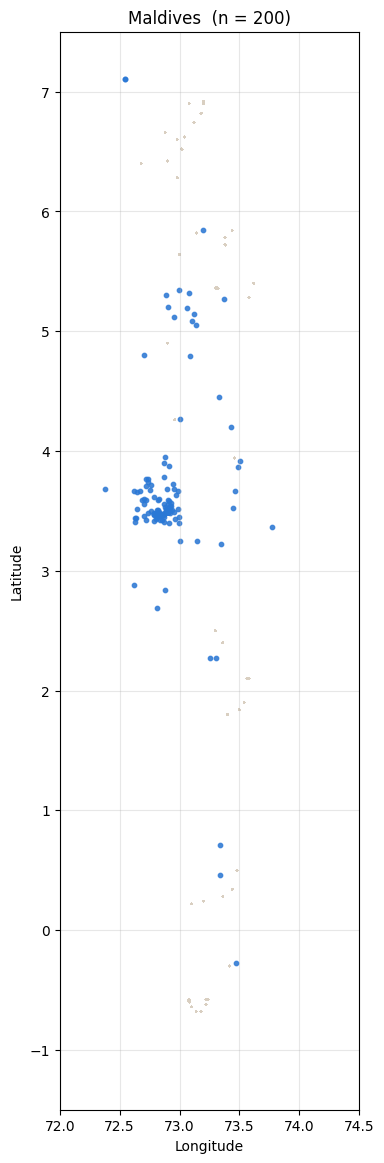

In [11]:
site = "Maldives"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

Central Maldives main area for sightings

###### Seychelles

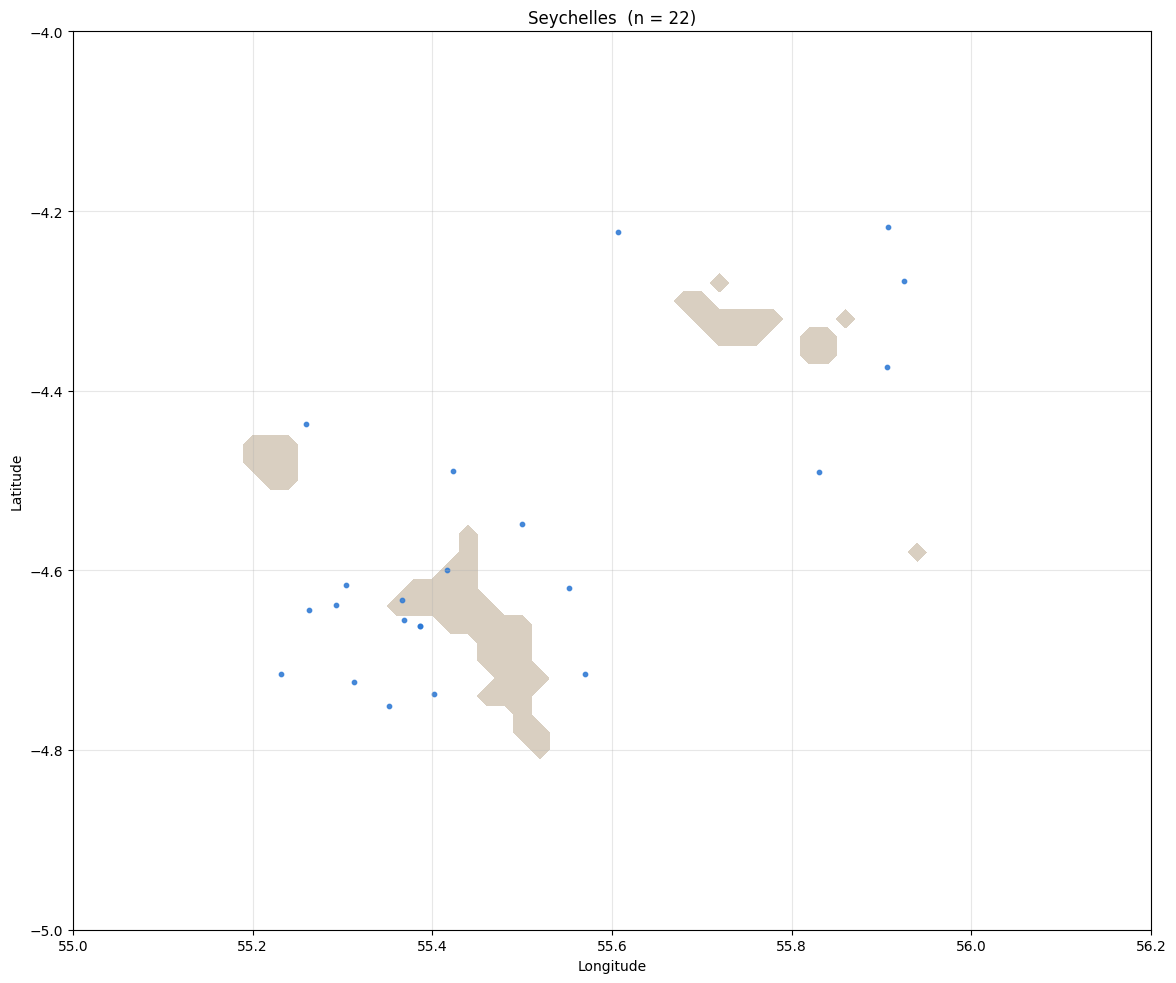

In [12]:
site = "Seychelles"
map_builder(db[db['site'] == site], site, bbox=(55.0, 56.2, -5.0, -4.0))

###### Red Sea / Djibouti

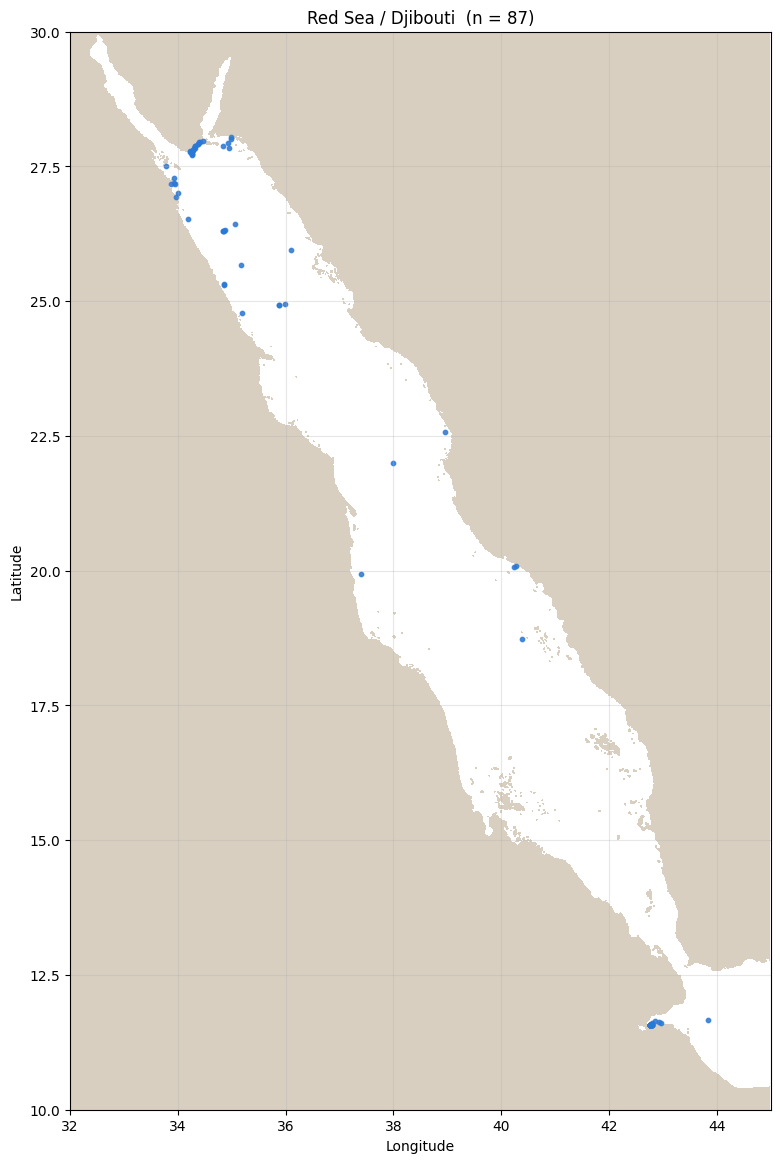

In [13]:
site = "Red Sea / Djibouti"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

northen part of read sea

###### Oman / Arabian Gulf

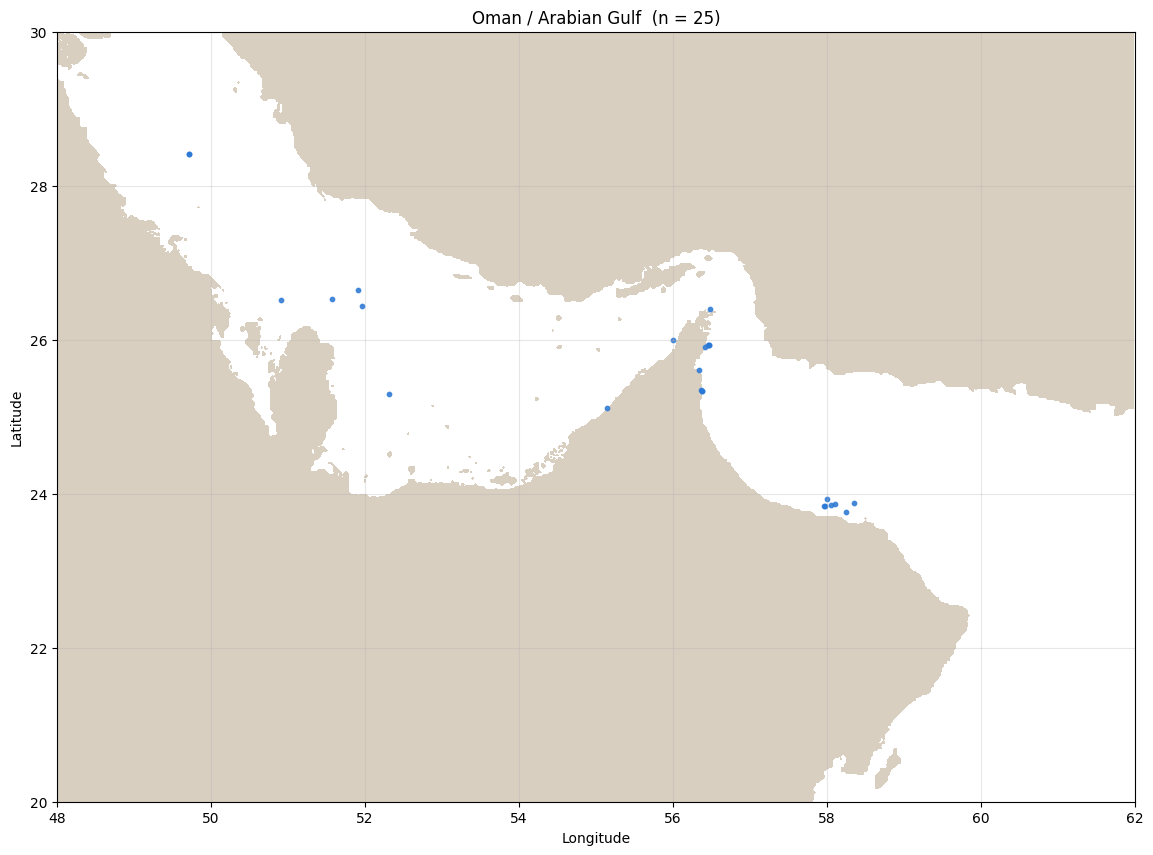

In [14]:
site = "Oman / Arabian Gulf"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

###### Andaman Sea / Thailand

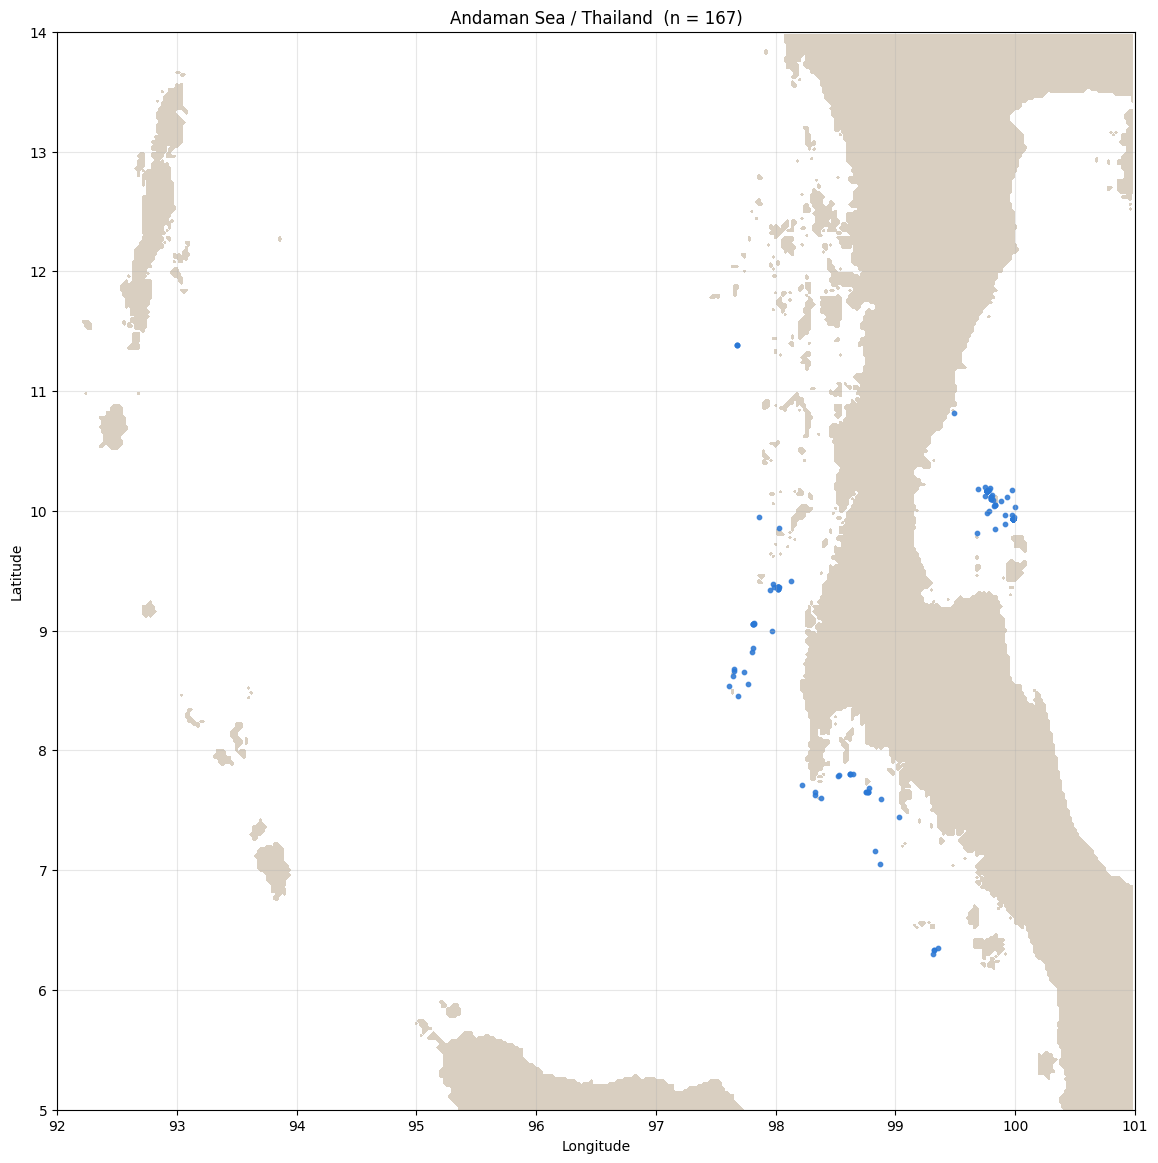

In [15]:
site = "Andaman Sea / Thailand"
map_builder(db[db['site'] == site], site, bbox=regions["Indian Ocean"][site])

##### **Western Pacific**

###### Philippines

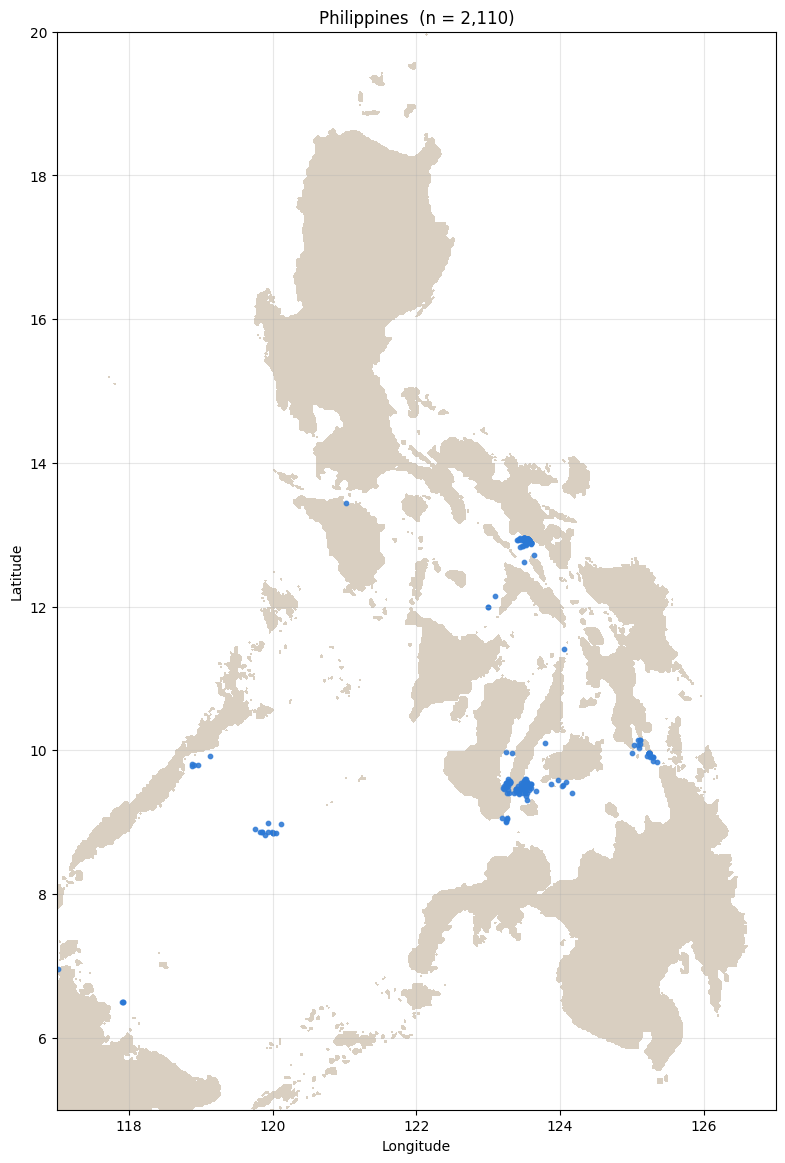

In [16]:
site = "Philippines"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### Taiwan / Japan

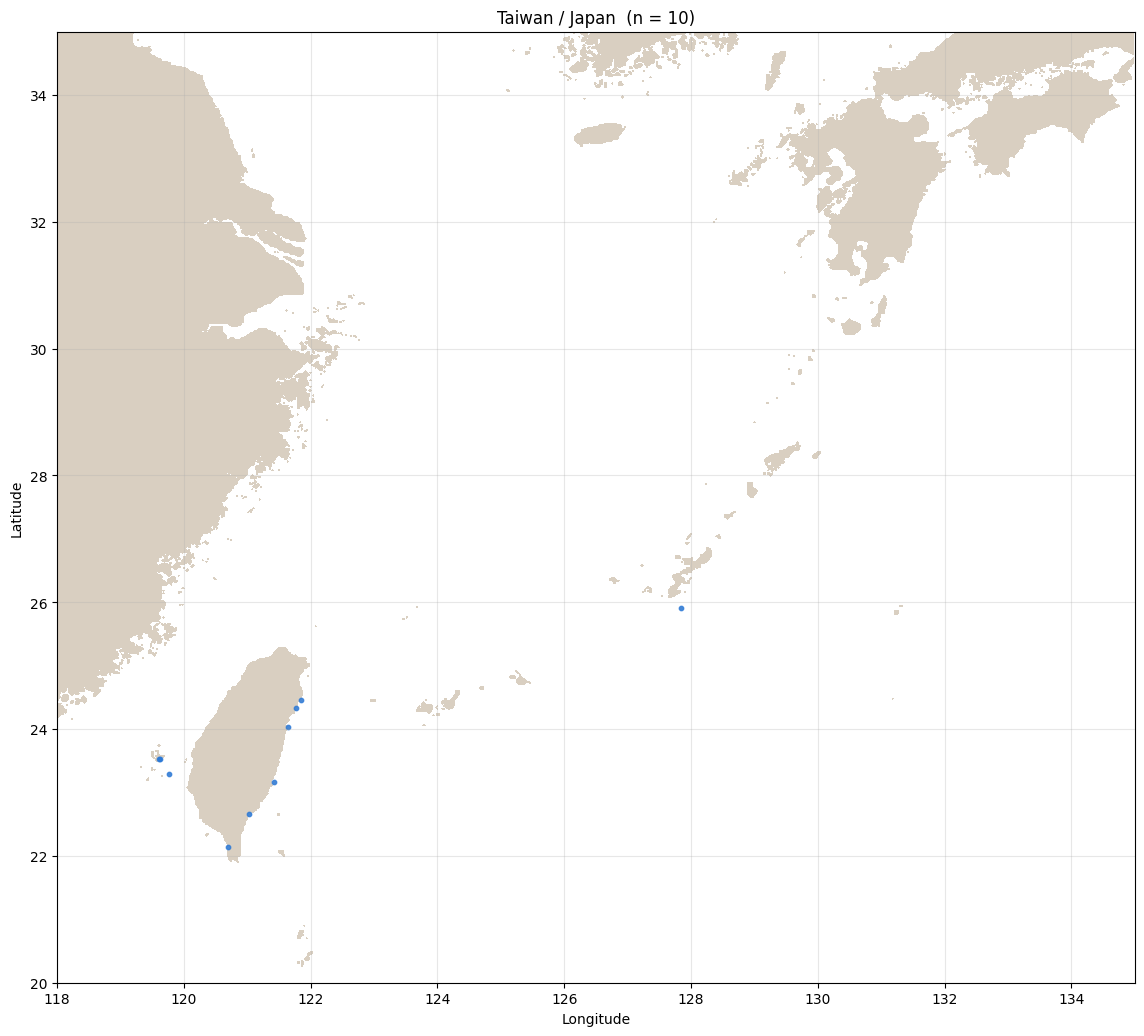

In [17]:
site = "Taiwan / Japan"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### Vietnam / Malaysia / Gulf of Thailand

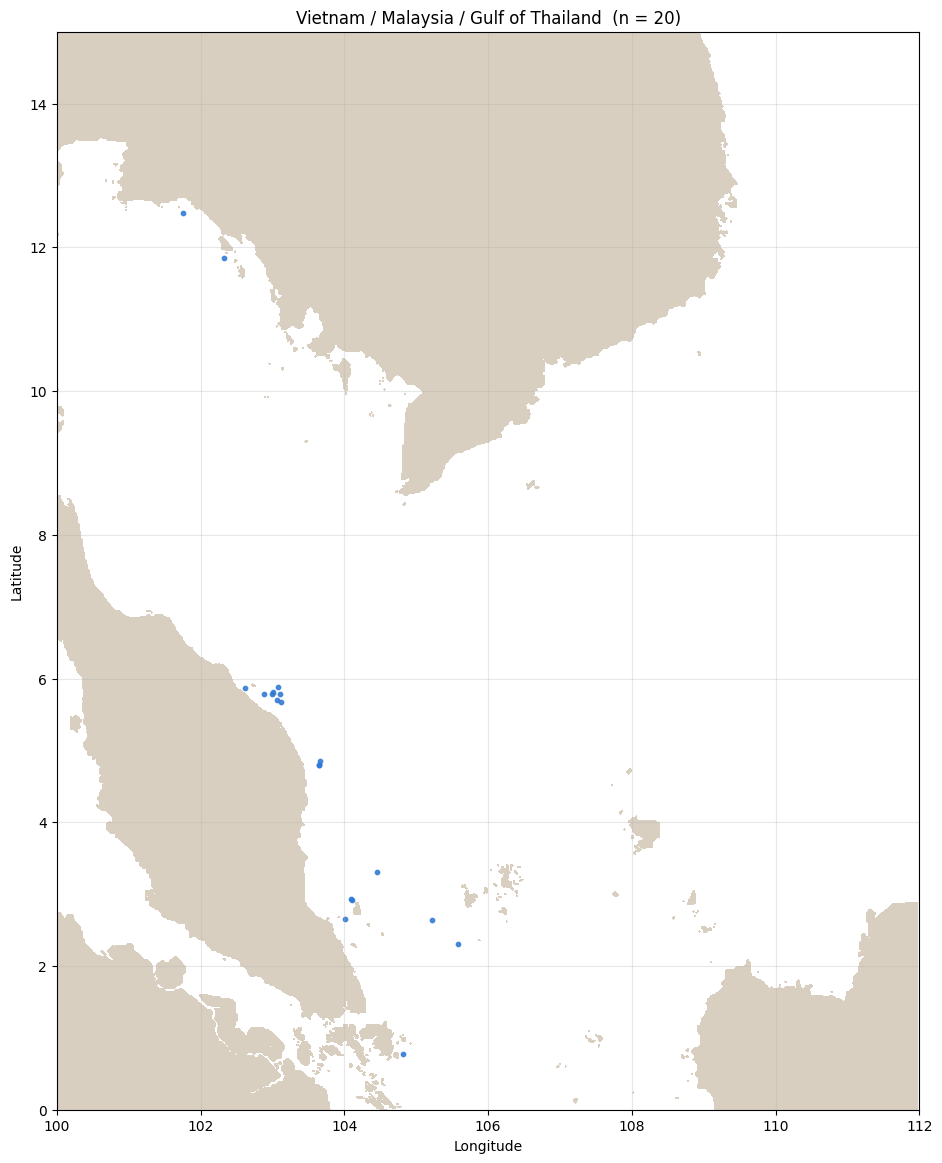

In [18]:
site = "Vietnam / Malaysia / Gulf of Thailand"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### NW Australia (Kimberley / NT)

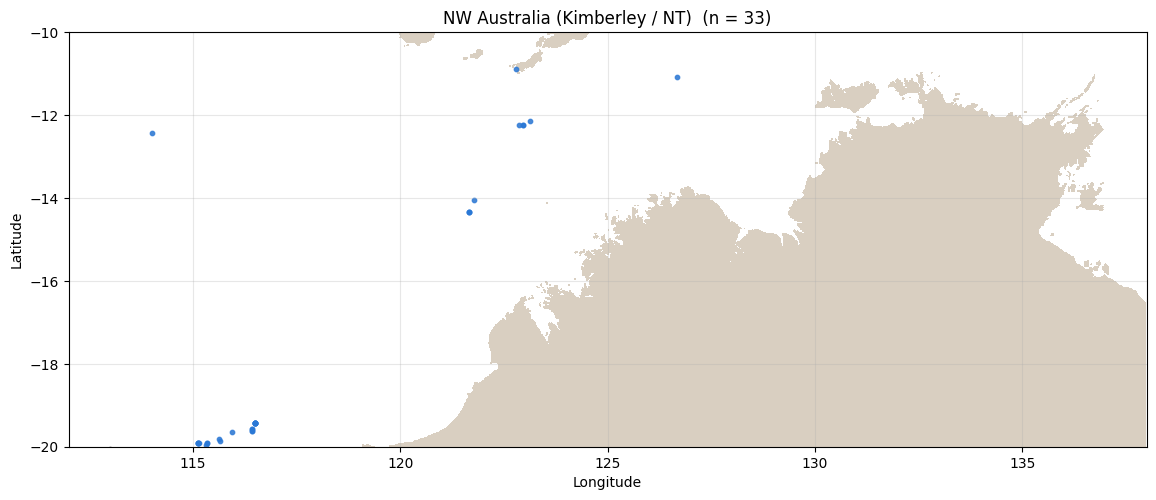

In [19]:
site = "NW Australia (Kimberley / NT)"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### Indonesia / Papua

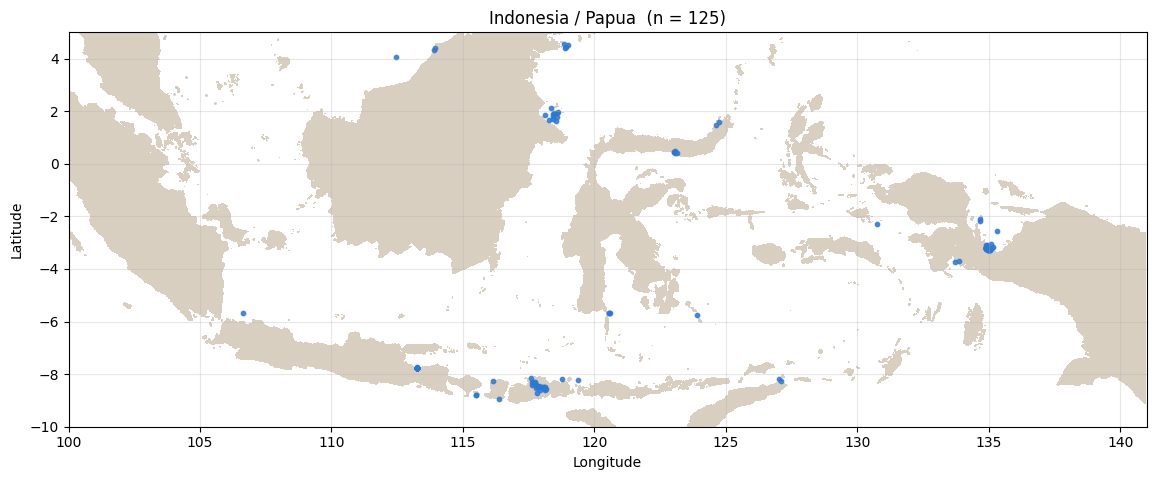

In [20]:
site = "Indonesia / Papua"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### Papua New Guinea / Solomon Is.

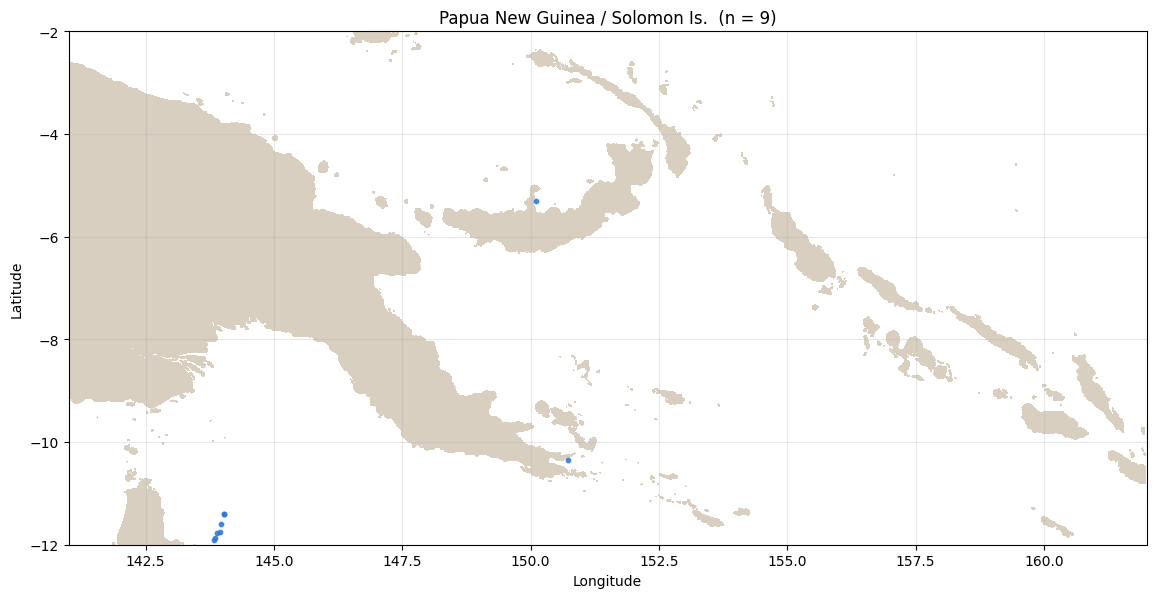

In [21]:
site = "Papua New Guinea / Solomon Is."
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### E Australia / New Caledonia

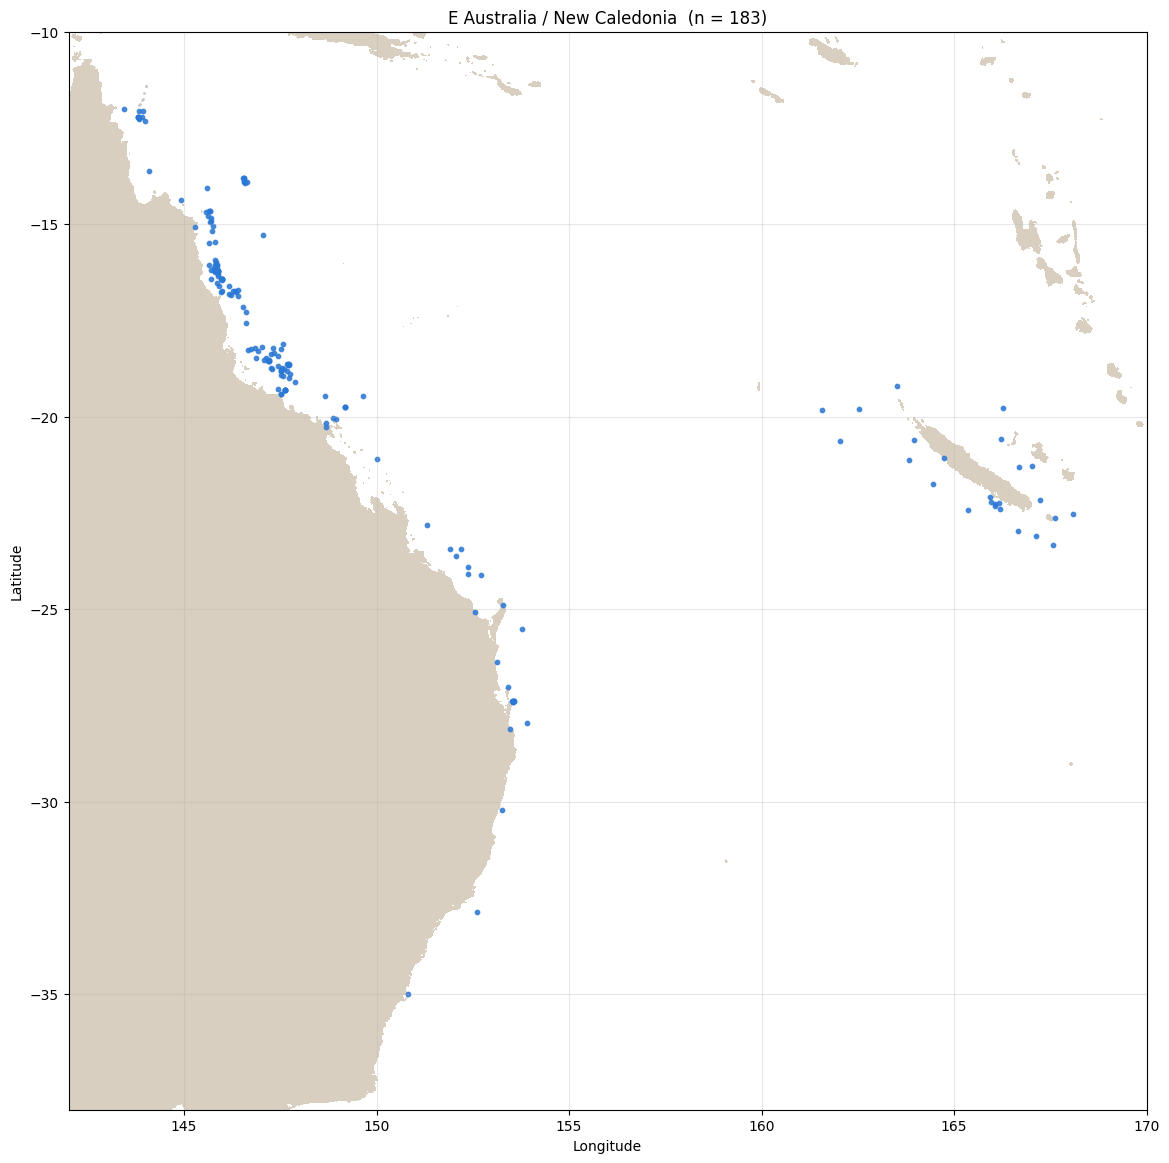

In [22]:
site = "E Australia / New Caledonia"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### New Zealand

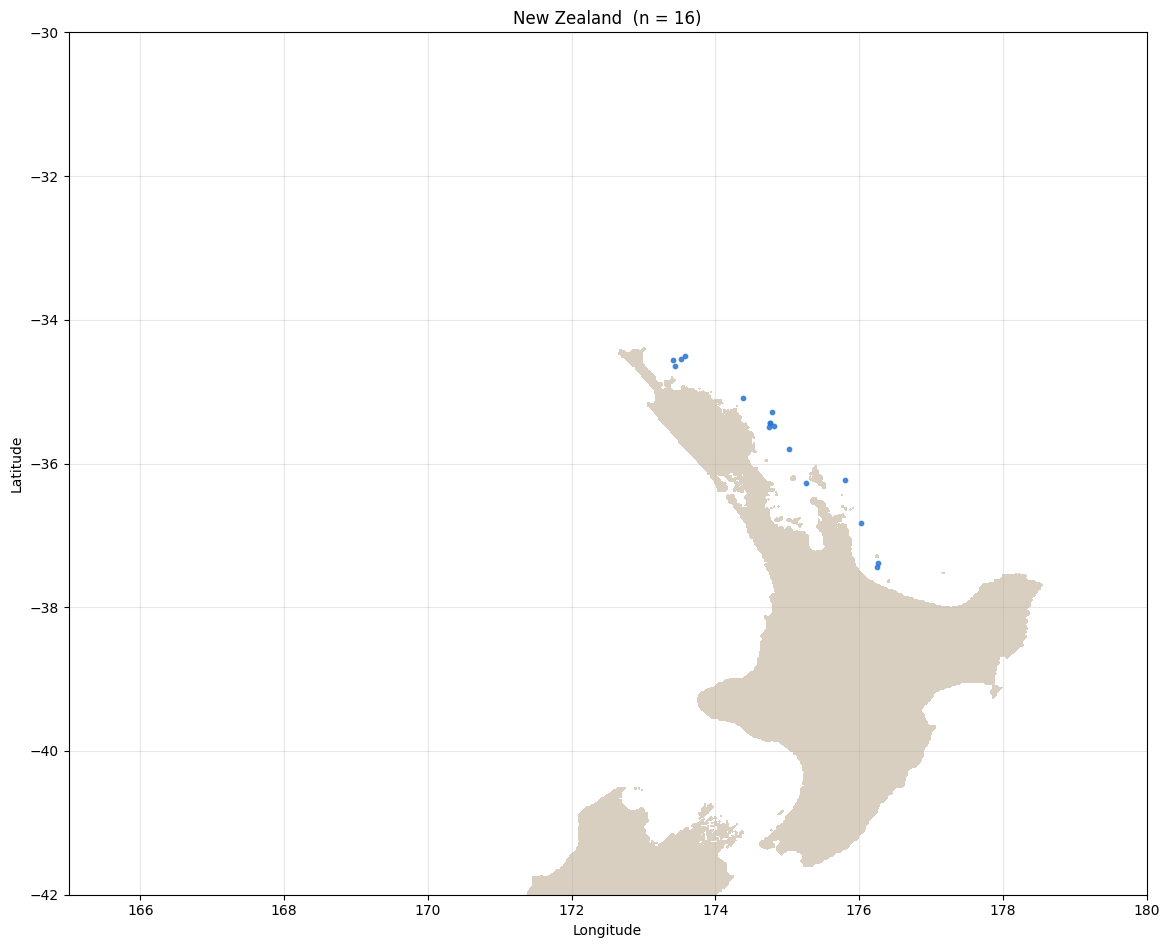

In [23]:
site = "New Zealand"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

###### Fiji / Tonga

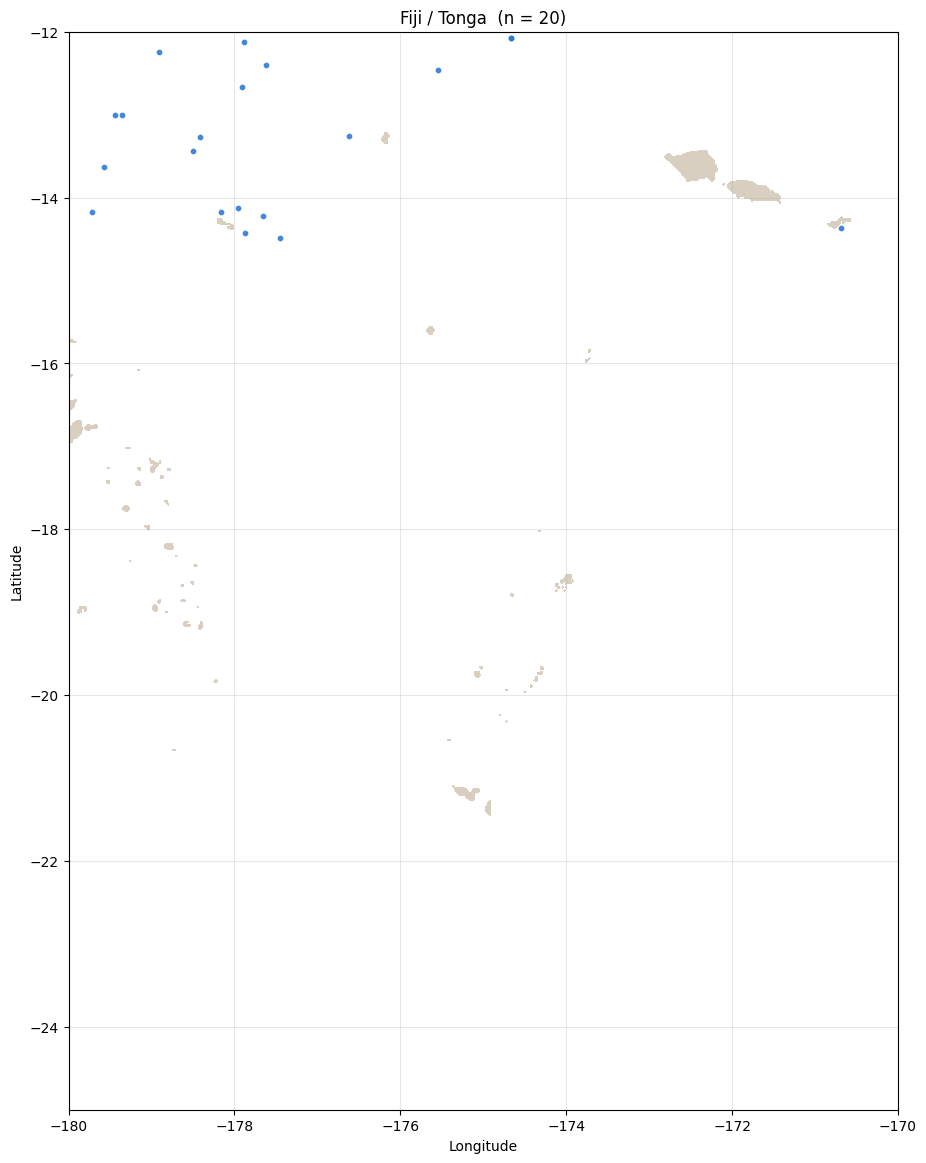

In [24]:
site = "Fiji / Tonga"
map_builder(db[db['site'] == site], site, bbox=regions["Western Pacific"][site])

##### **Central Pacific**

###### Hawaii

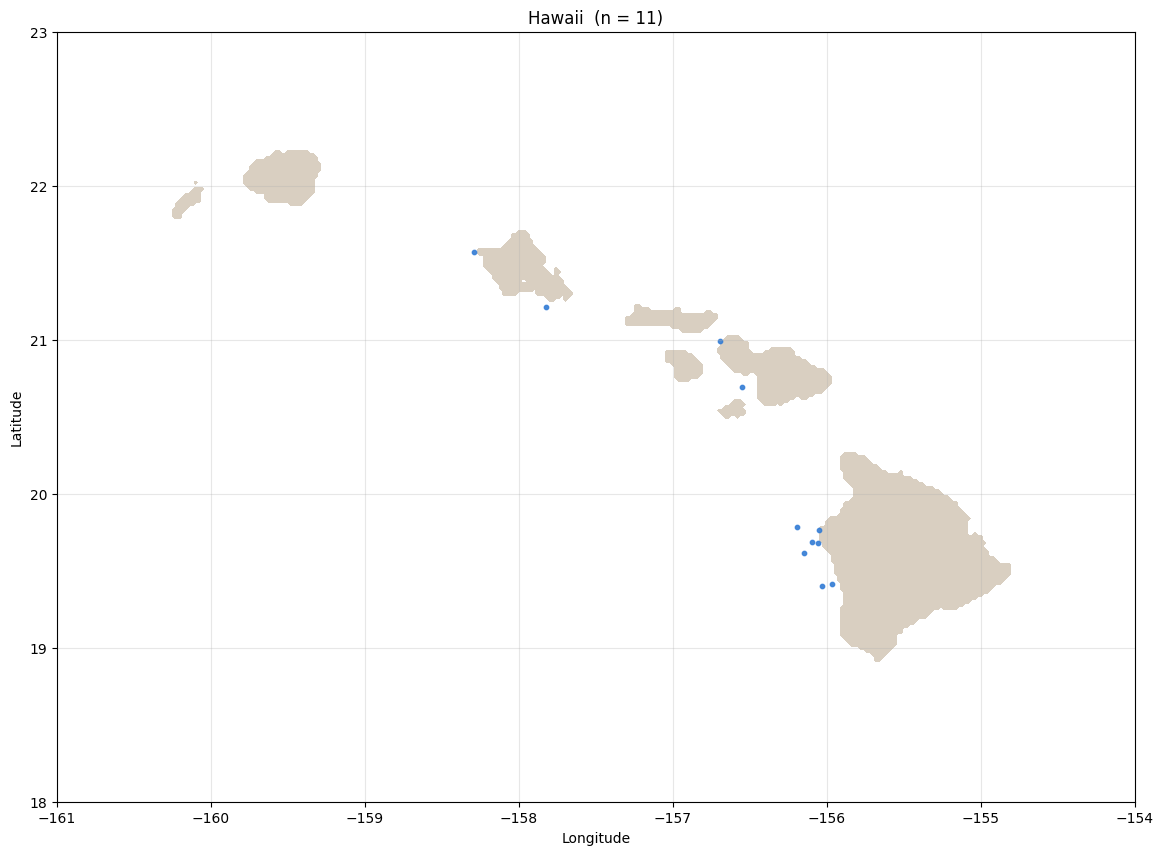

In [25]:
site = "Hawaii"
map_builder(db[db['site'] == site], site, bbox=regions["Central Pacific"][site])

###### French Polynesia

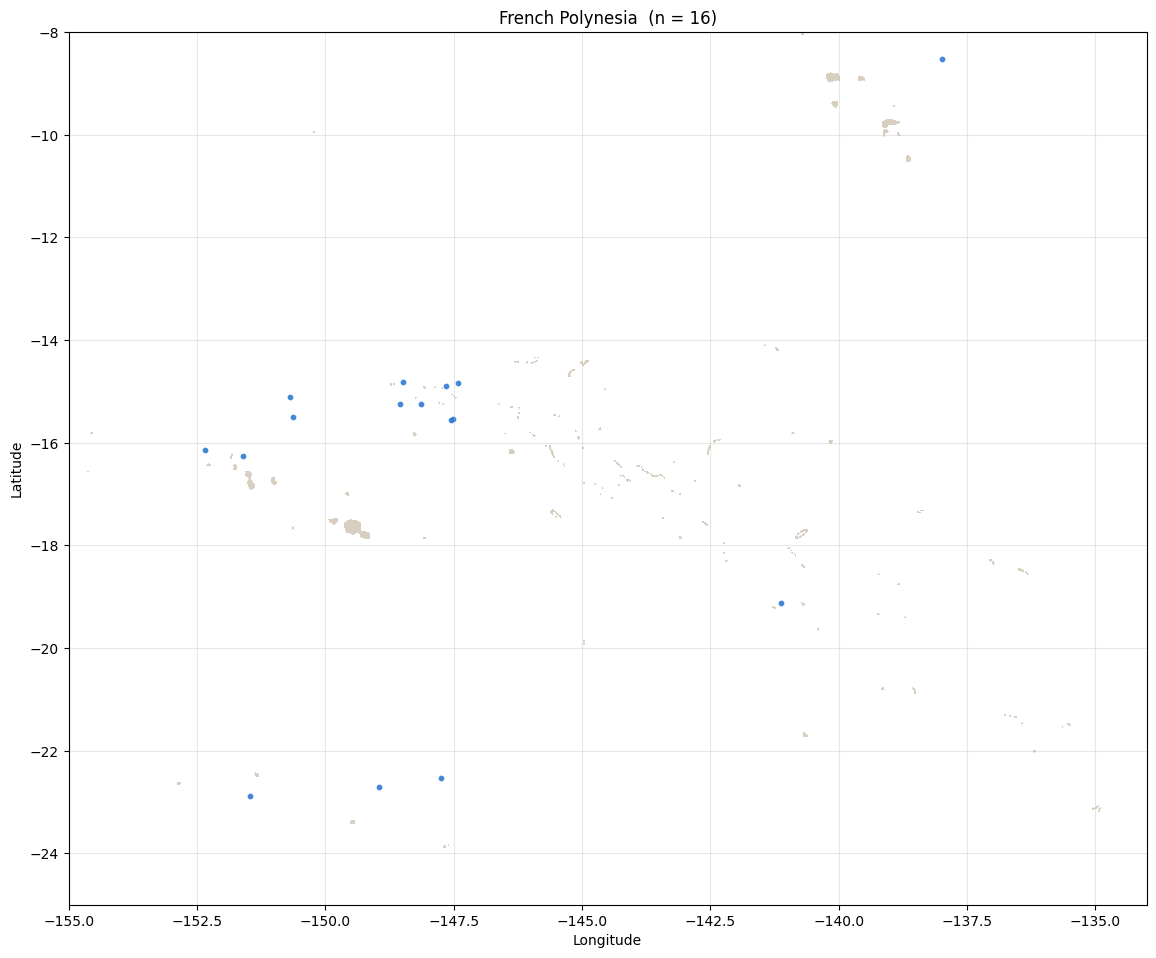

In [26]:
site = "French Polynesia"
map_builder(db[db['site'] == site], site, bbox=regions["Central Pacific"][site])

##### **Eastern Pacific**

###### Mexican Pacific / Gulf of California

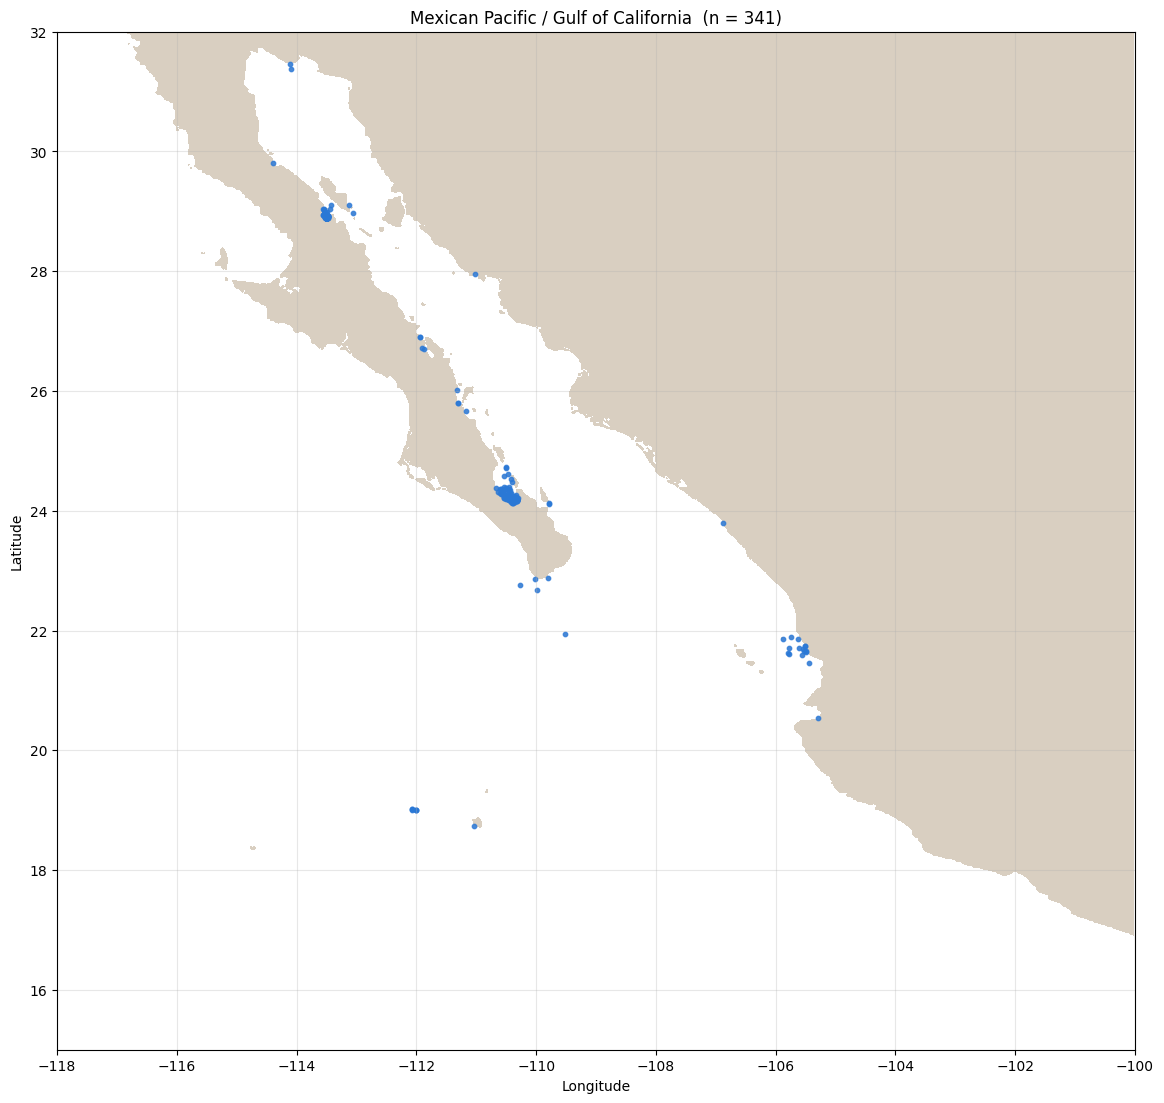

In [27]:
site = "Mexican Pacific / Gulf of California"
map_builder(db[db['site'] == site], site, bbox=regions["Eastern Pacific"][site])

###### Galápagos / Panama / Ecuador

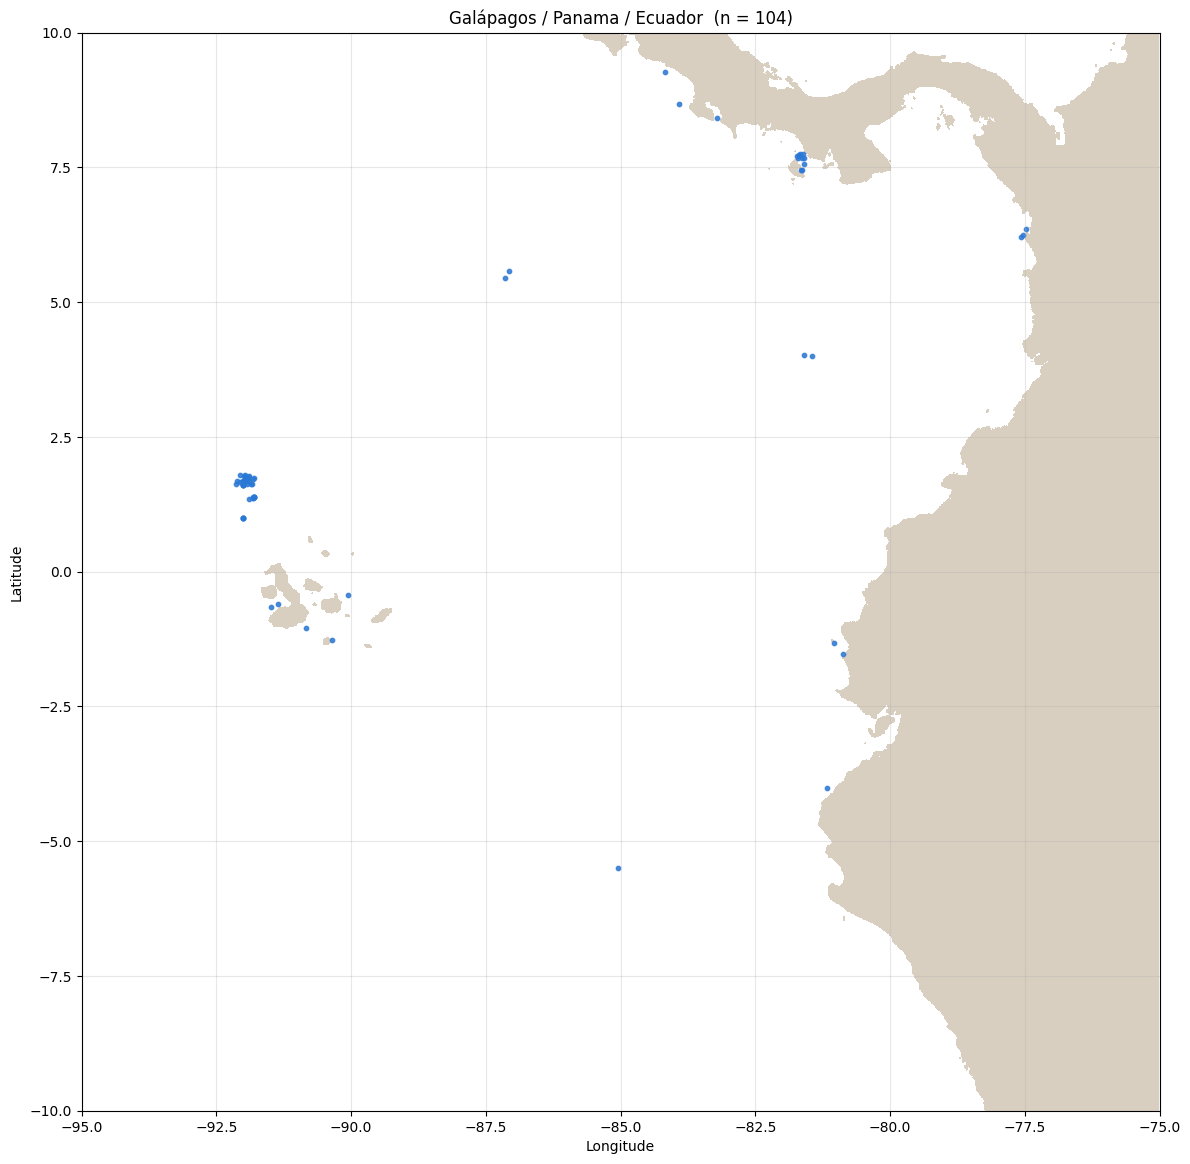

In [28]:
site = "Galápagos / Panama / Ecuador"
map_builder(db[db['site'] == site], site, bbox=regions["Eastern Pacific"][site])

##### **Atlantic**

###### Gulf of Mexico / Caribbean

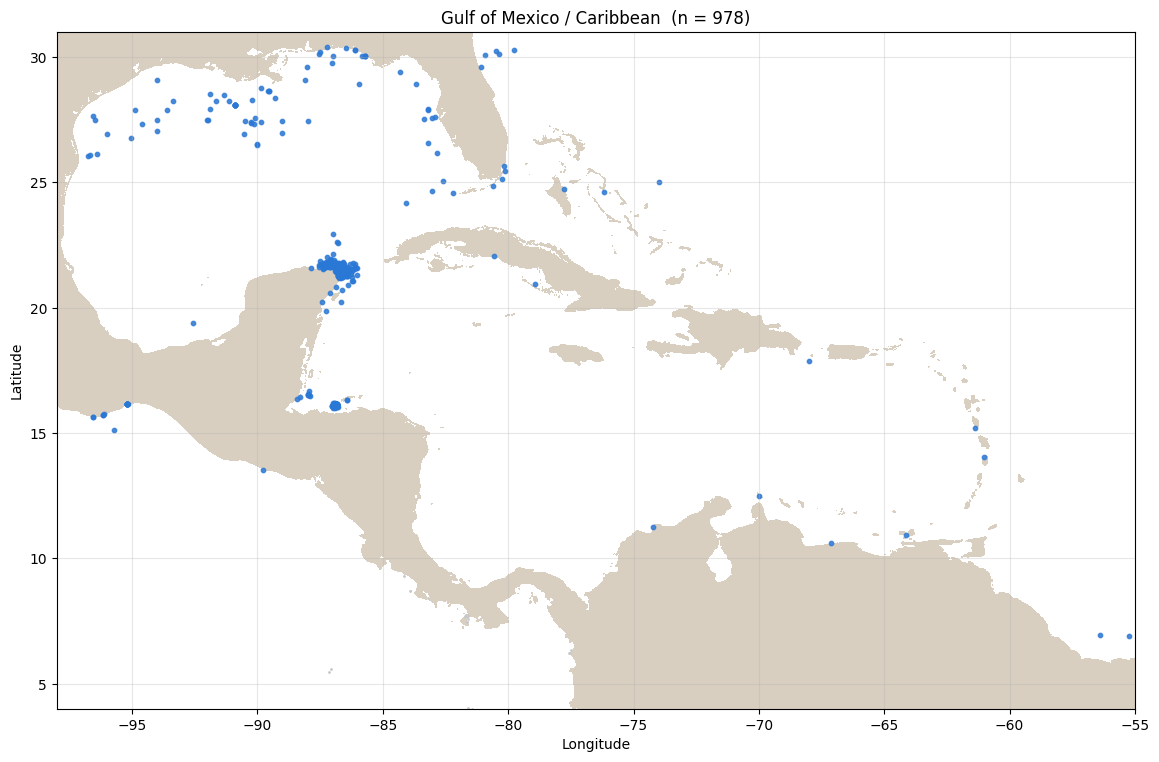

In [29]:
site = "Gulf of Mexico / Caribbean"
map_builder(db[db['site'] == site], site, bbox=regions["Atlantic"][site])

###### US East Coast / Florida

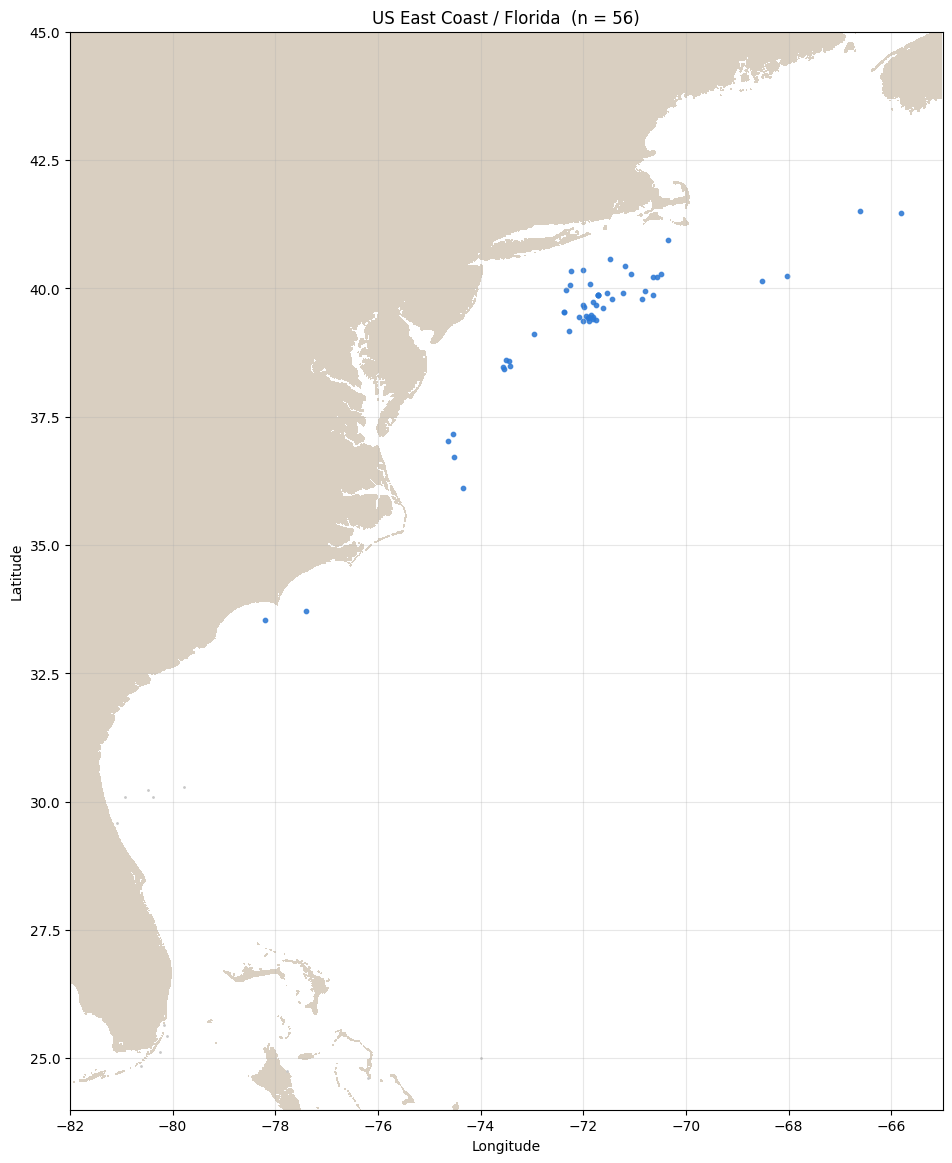

In [30]:
site = "US East Coast / Florida"
map_builder(db[db['site'] == site], site, bbox=regions["Atlantic"][site])

###### Brazil / St Helena

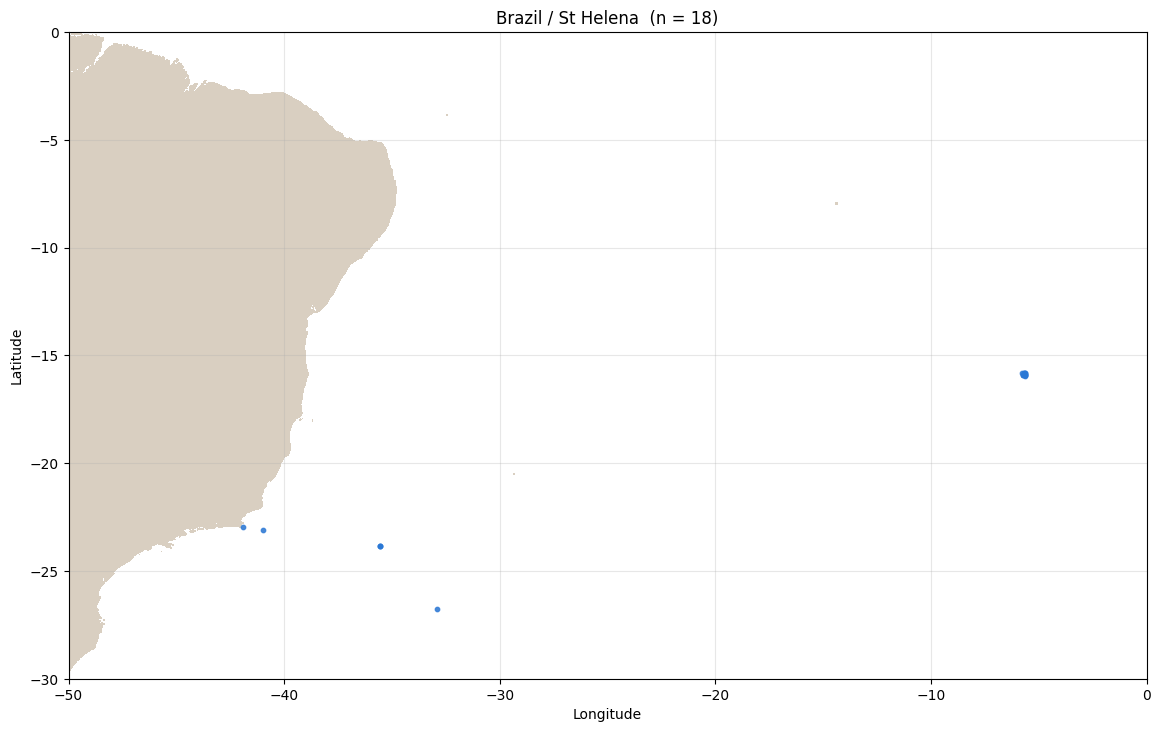

In [31]:
site = "Brazil / St Helena"
map_builder(db[db['site'] == site], site, bbox=regions["Atlantic"][site])

###### Azores / Canaries / W Africa

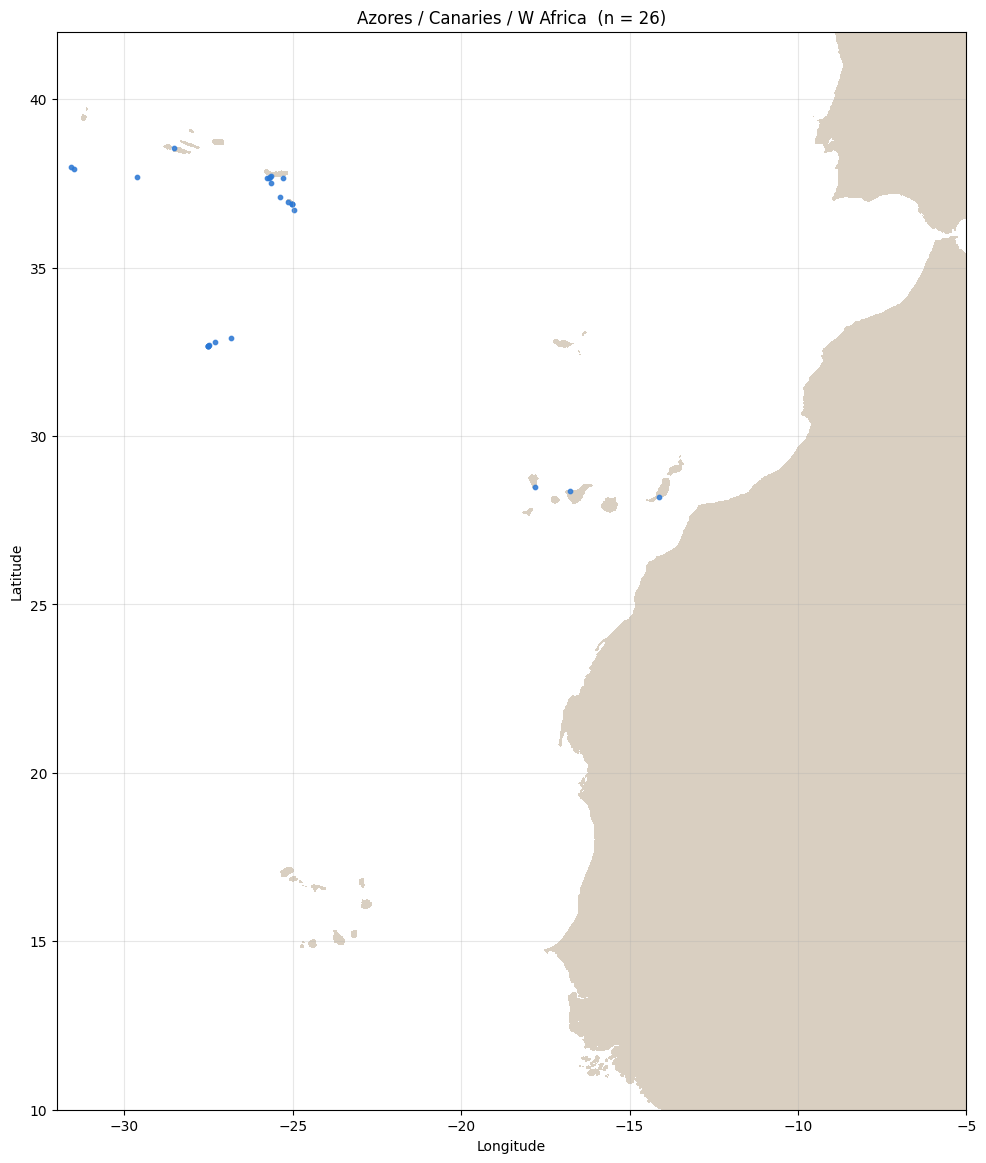

In [32]:
site = "Azores / Canaries / W Africa"
map_builder(db[db['site'] == site], site, bbox=regions["Atlantic"][site])

### 2) Seasonal maps

Twelve world maps, one per month. Grey points = all sightings, blue = sightings recorded in that month.

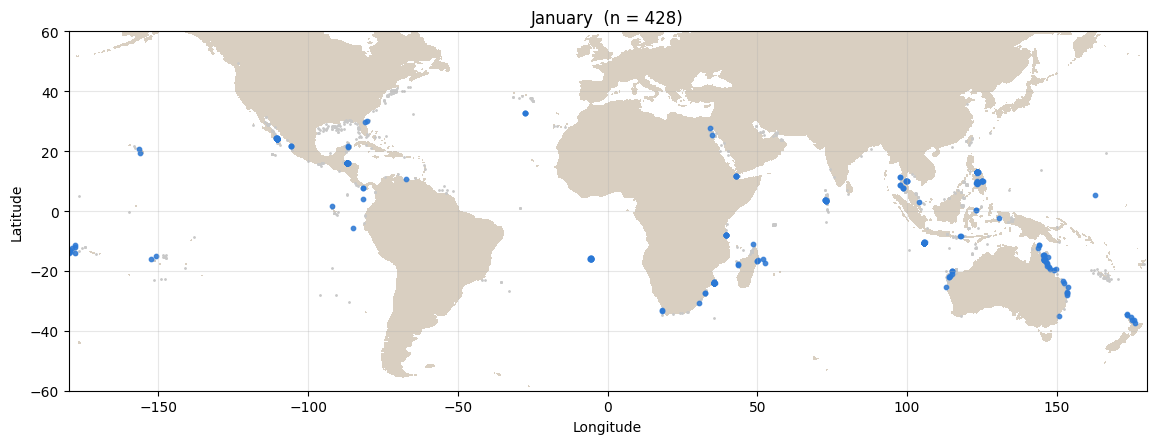

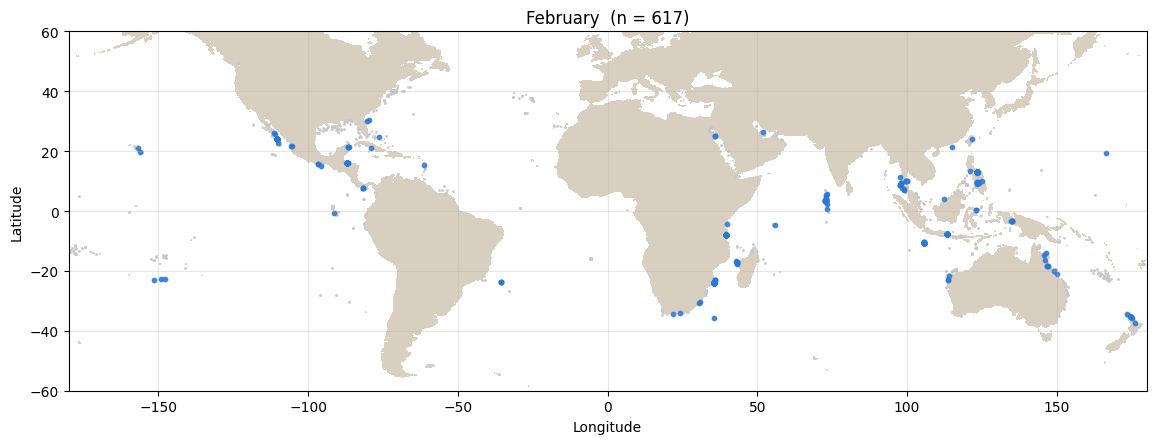

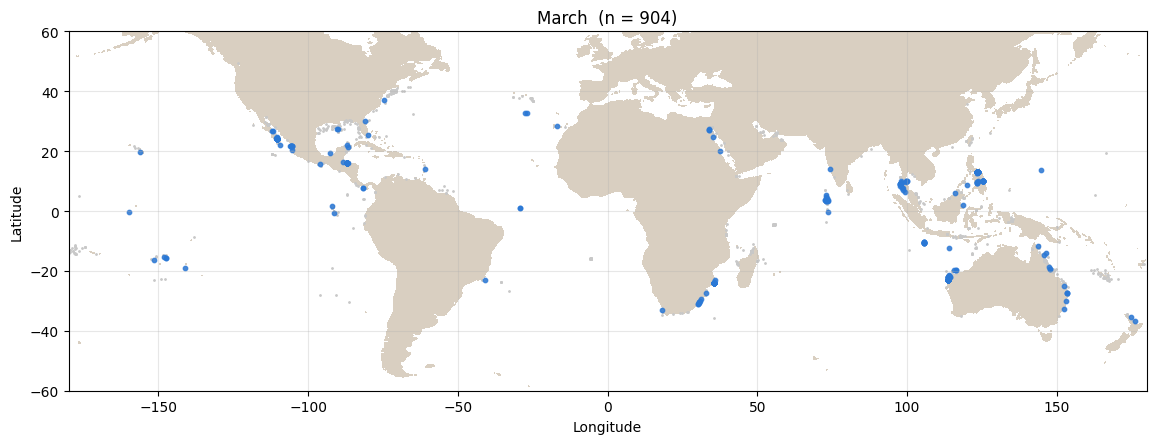

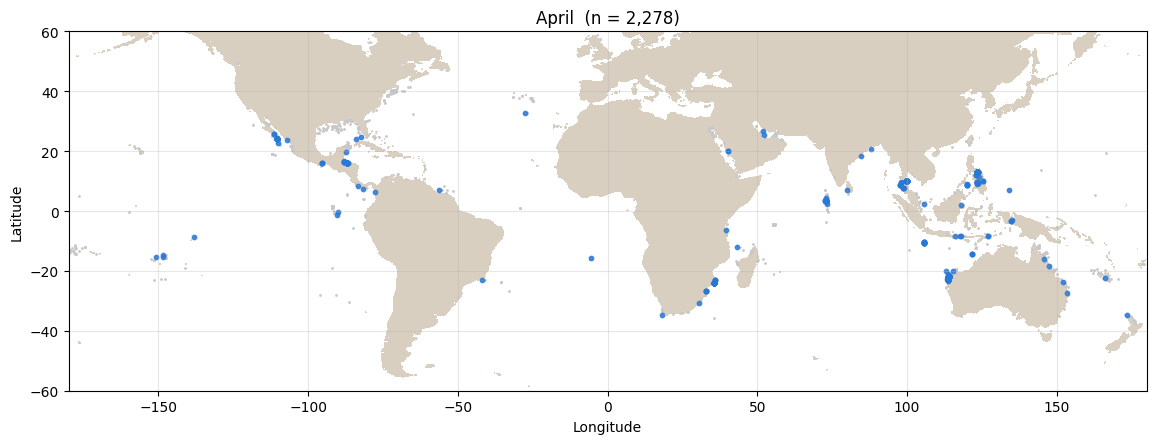

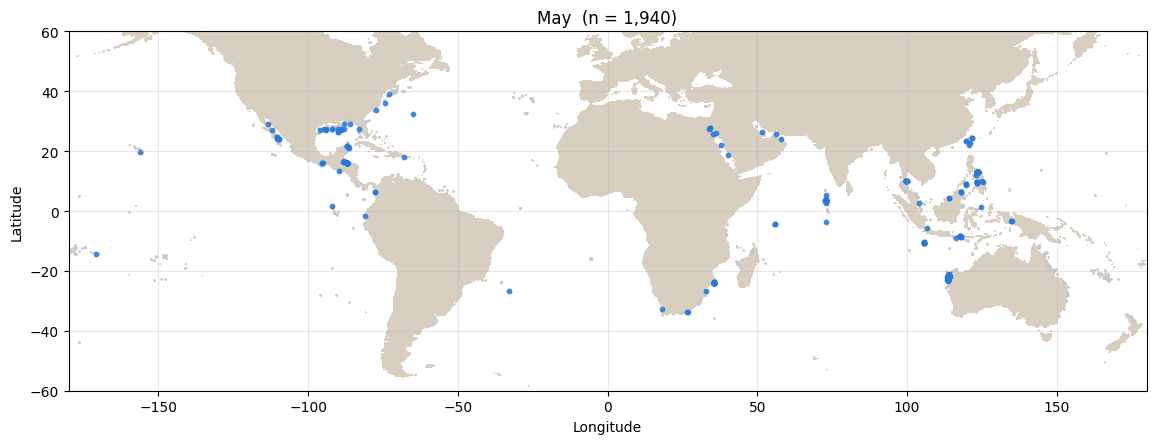

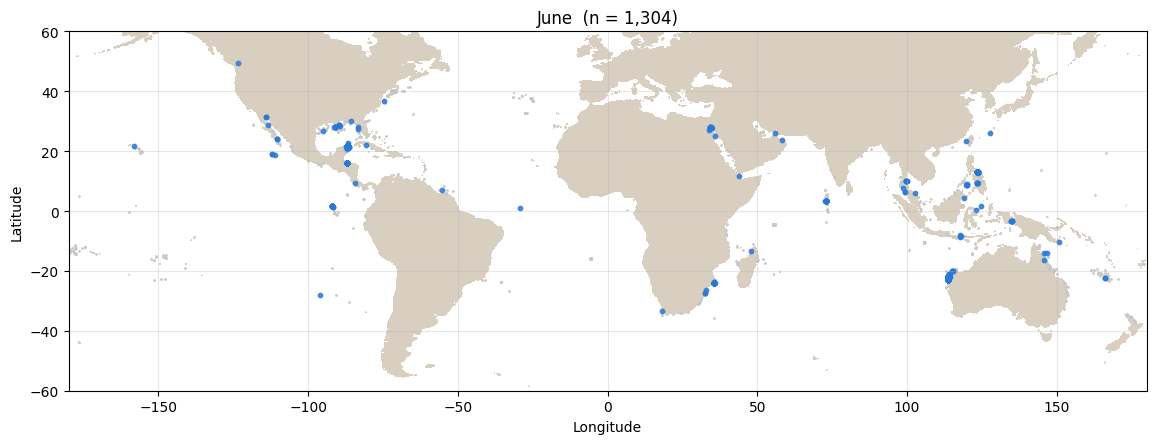

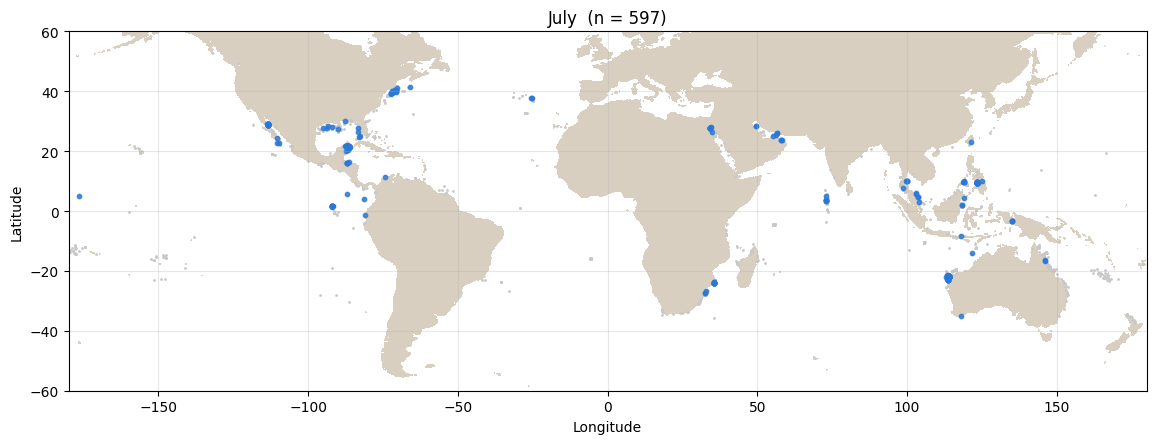

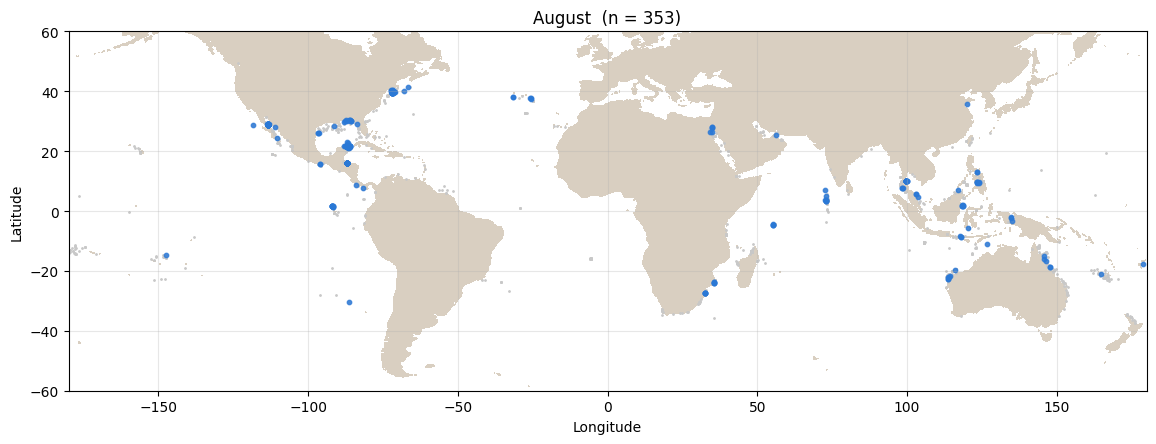

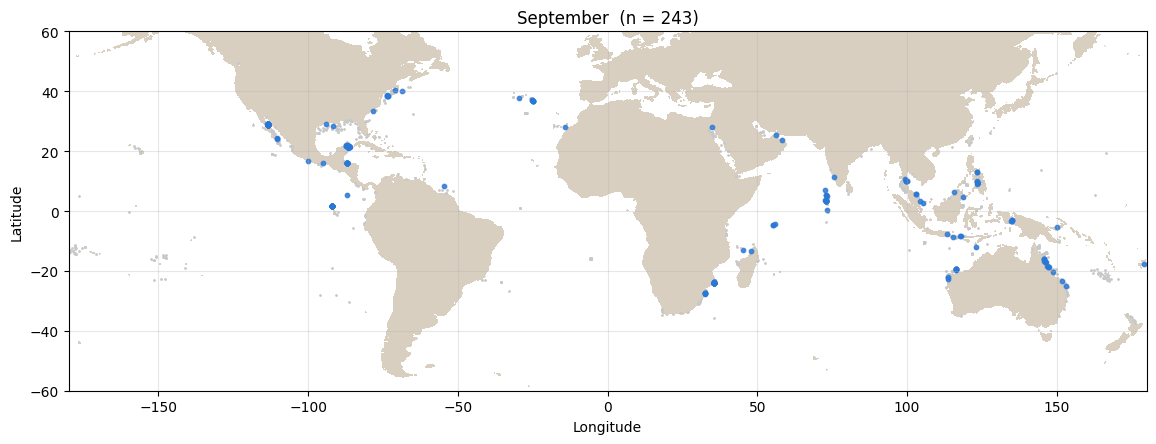

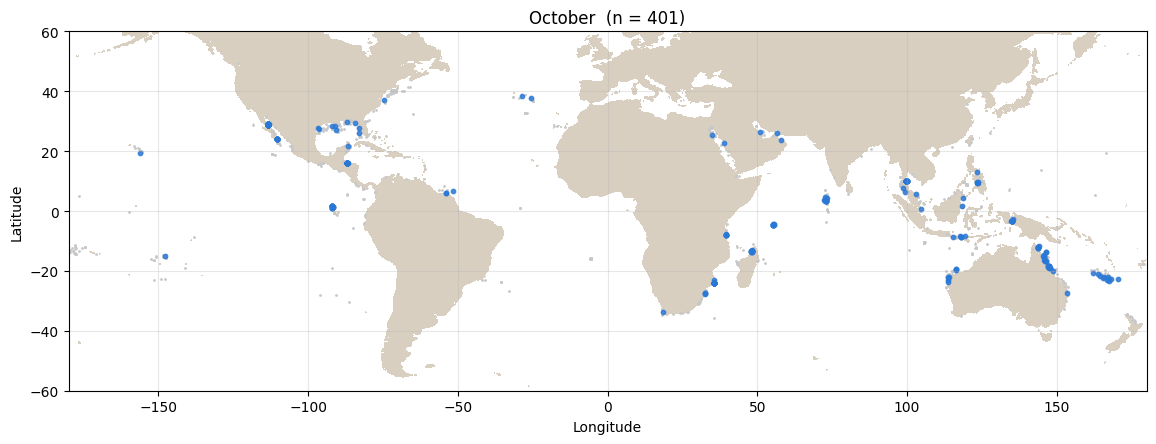

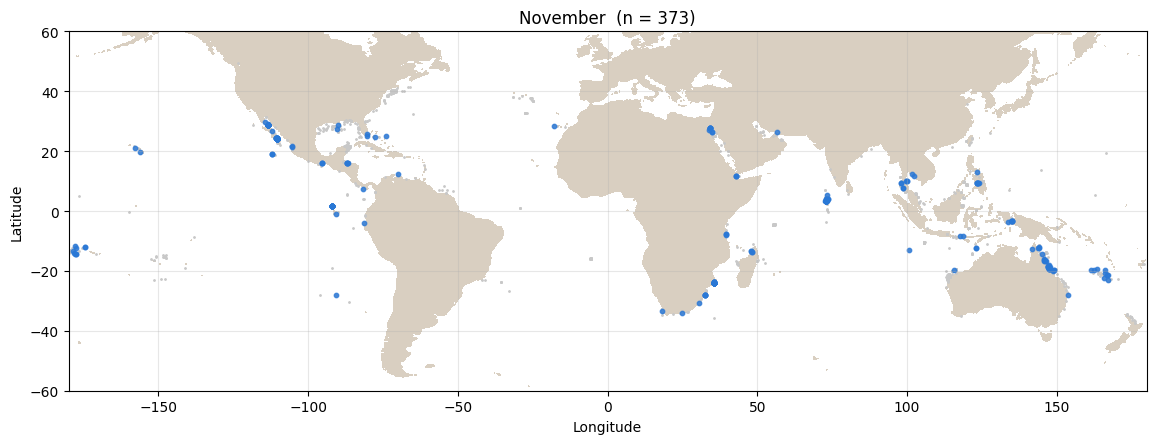

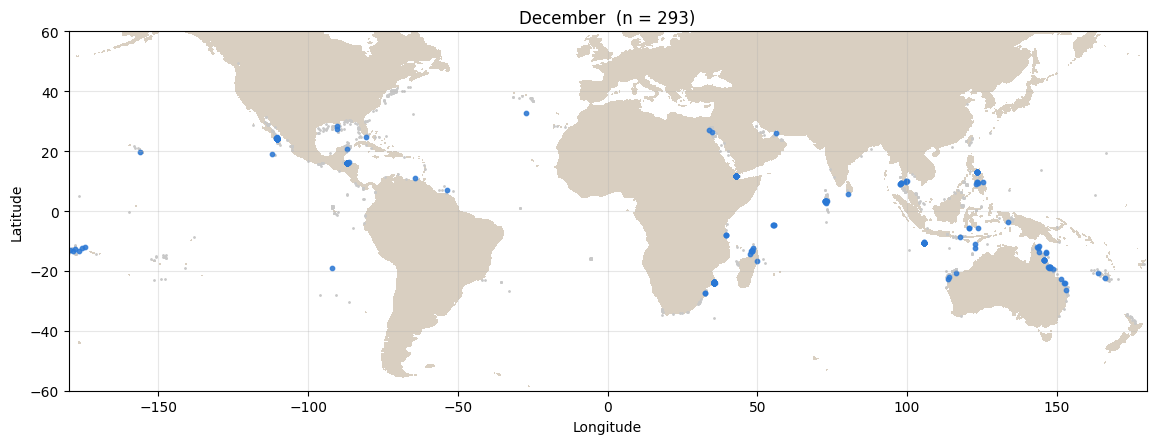

In [33]:
import calendar
for m in range(1, 13):
    map_builder(db[db['month'] == m], calendar.month_name[m])

Sightings per month for the main sites (the maps alone look alike; the table makes the seasonality readable).

In [38]:
top_sites = db['site'].value_counts().head(10).index
tab = pd.crosstab(db[db['site'].isin(top_sites)]['site'], db['month'])
tab.columns = [calendar.month_abbr[m] for m in tab.columns]
tab = tab.loc[db['site'].value_counts().head(10).index]
tab

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
site,,,,,,,,,,,,
Ningaloo Reef (W Australia),4,3,90,1119,1394,1031,318,5,2,4,0,2
Philippines,87,279,554,788,303,31,24,9,6,5,8,16
Gulf of Mexico / Caribbean,40,47,86,144,48,120,144,192,82,27,15,33
Mozambique / Tanzania / Kenya,89,154,45,99,77,31,14,10,27,160,166,90
Mexican Pacific / Gulf of California,37,18,33,18,7,8,19,32,29,55,52,33
Maldives,11,16,13,29,41,18,5,8,13,11,23,12
E Australia / New Caledonia,33,8,11,5,0,5,2,6,12,40,36,25
Andaman Sea / Thailand,13,15,21,28,14,9,5,18,6,23,7,8
Other,53,18,15,15,10,3,2,4,5,4,4,23


Same table as a share of each site's total (each row sums to 100%), so sites of different size can be compared.

In [41]:
pct = (tab.div(tab.sum(axis=1), axis=0) * 100).round(0).astype(int)

def color_pct(v):
    if v == 0:    return "background-color: #e34948; color: white; font-weight: bold"
    elif v < 4:   return "background-color: #f8b878; color: black"
    elif v < 10:  return "background-color: #f7ea80; color: black"
    elif v < 16:  return "background-color: #c9e8a5; color: black"
    elif v < 22:  return "background-color: #3f8f2f; color: white; font-weight: bold"
    elif v < 28:  return "background-color: #a9d6f5; color: black"
    else:         return "background-color: #1f5fff; color: white; font-weight: bold"

pct.style.map(color_pct)


,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
site,,,,,,,,,,,,
Ningaloo Reef (W Australia),0,0,2,28,35,26,8,0,0,0,0,0
Philippines,4,13,26,37,14,1,1,0,0,0,0,1
Gulf of Mexico / Caribbean,4,5,9,15,5,12,15,20,8,3,2,3
Mozambique / Tanzania / Kenya,9,16,5,10,8,3,1,1,3,17,17,9
Mexican Pacific / Gulf of California,11,5,10,5,2,2,6,9,9,16,15,10
Maldives,6,8,6,14,20,9,2,4,6,6,12,6
E Australia / New Caledonia,18,4,6,3,0,3,1,3,7,22,20,14
Andaman Sea / Thailand,8,9,13,17,8,5,3,11,4,14,4,5
Other,34,12,10,10,6,2,1,3,3,3,3,15


### 3) SST (Sea Surface Temperature) maps

Classes chosen from the distribution of `sst_cmems` so that every map has enough points. Records without a value are not shown.

In [42]:
print(db['sst_cmems'].describe().round(2))
db['sst_cmems_class'] = pd.cut(db['sst_cmems'], bins=[-99, 22, 24, 26, 28, 30, 99], labels=["< 22", "22–24", "24–26", "26–28", "28–30", "> 30"])
db['sst_cmems_class'].value_counts().sort_index()

count    9600.00
mean       27.00
std         1.77
min        10.67
25%        26.08
50%        27.25
75%        28.16
max        32.54
Name: sst_cmems, dtype: float64


,count
sst_cmems_class,
< 22,123
22–24,310
24–26,1816
26–28,4592
28–30,2558
> 30,201


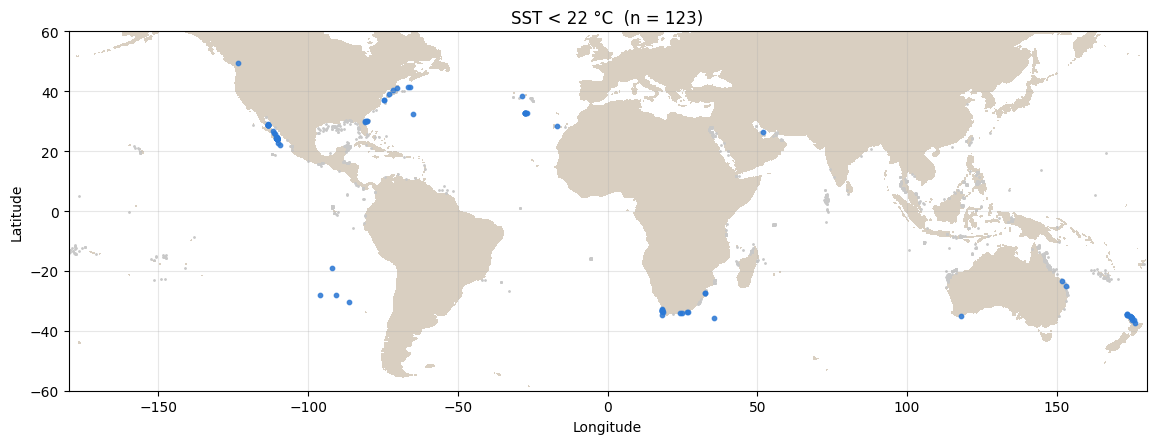

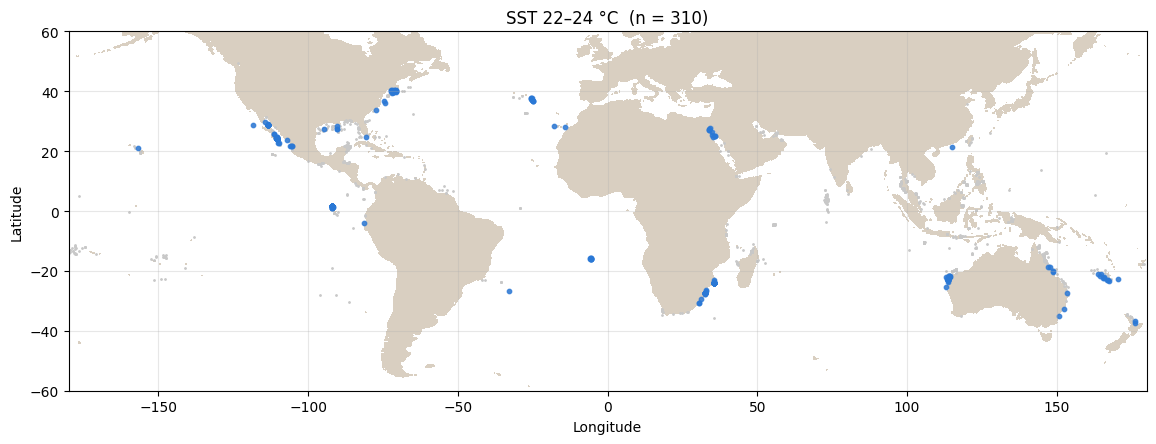

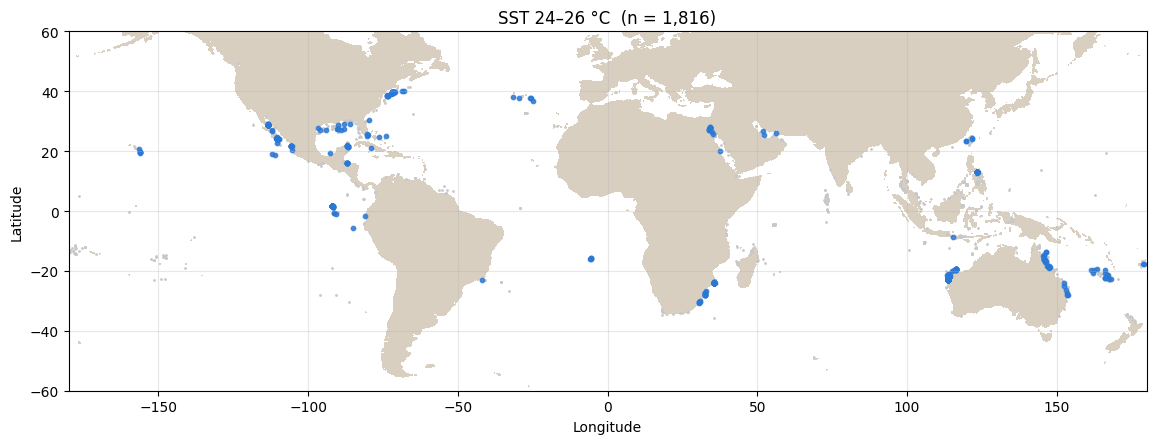

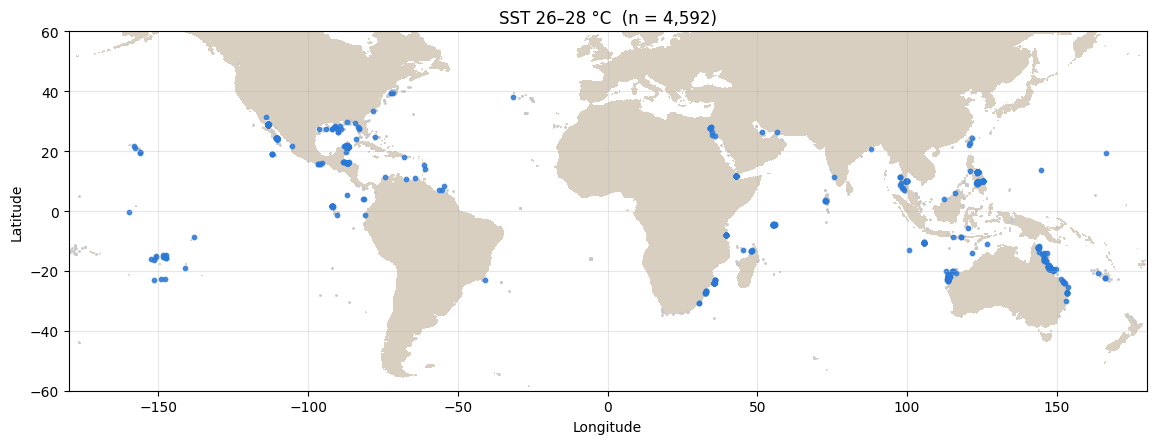

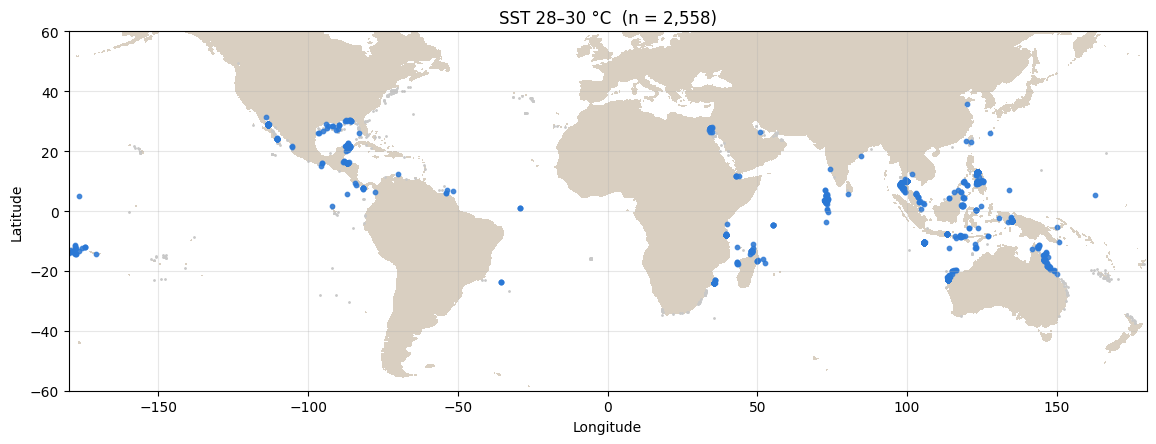

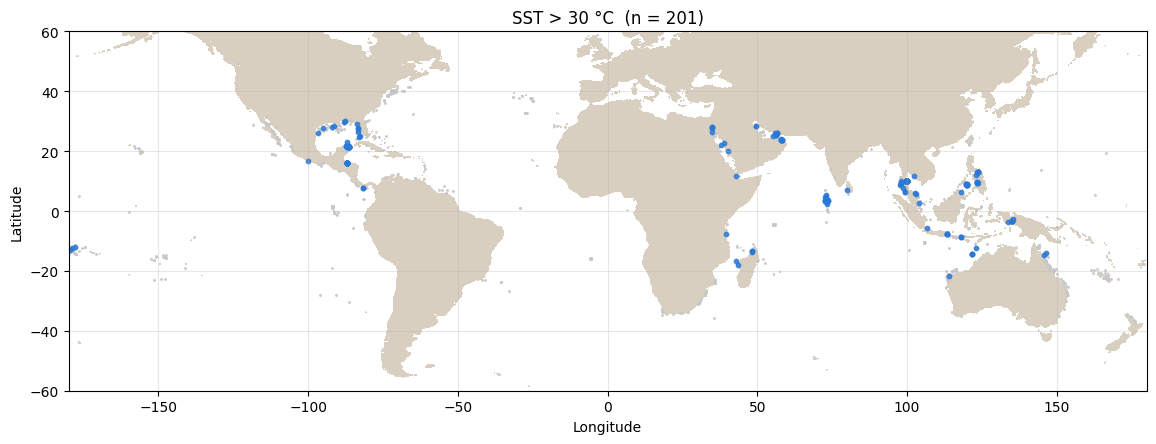

In [43]:
for cl in db['sst_cmems_class'].cat.categories:
    map_builder(db[db['sst_cmems_class'] == cl], f"SST {cl} °C")

### 4) Bathymetry maps

Classes chosen from the distribution of `bathymetry` so that every map has enough points. Records without a value are not shown.

In [44]:
print(db['bathymetry'].describe().round(2))
db['bathymetry_class'] = pd.cut(db['bathymetry'], bins=[-9999, 0, 10, 20, 50, 100, 200, 1000, 99999], labels=["on land (≤ 0)", "0–10", "10–20", "20–50", "50–100", "100–200", "200–1000", "> 1000"])
db['bathymetry_class'].value_counts().sort_index()

count    9731.00
mean      128.86
std       395.51
min      -105.00
25%        33.00
50%        55.00
75%        82.00
max      5365.00
Name: bathymetry, dtype: float64


,count
bathymetry_class,
on land (≤ 0),149
0–10,1147
10–20,363
20–50,2652
50–100,4077
100–200,651
200–1000,445
> 1000,247


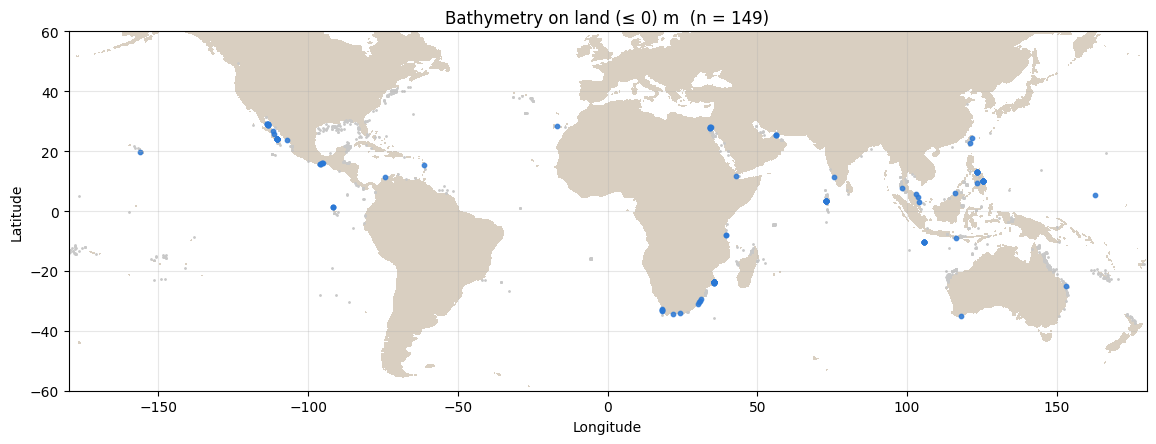

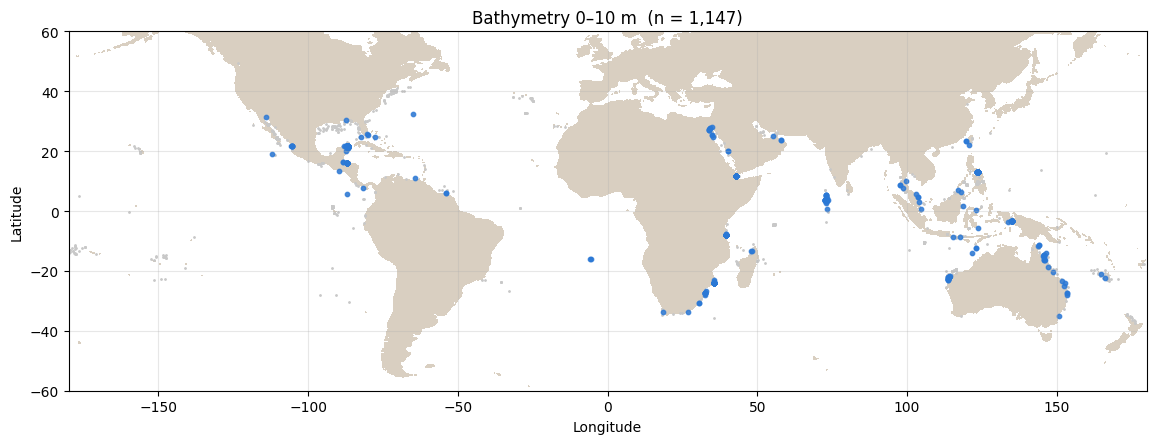

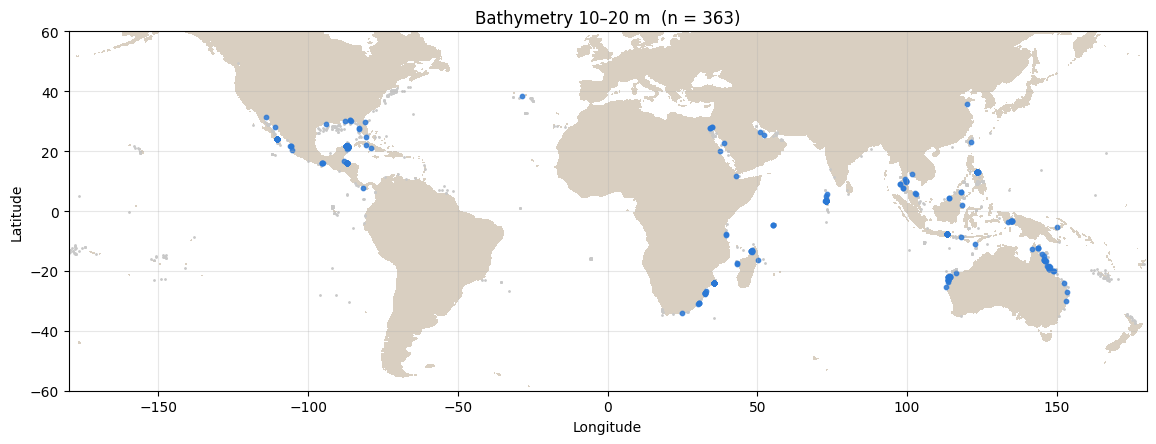

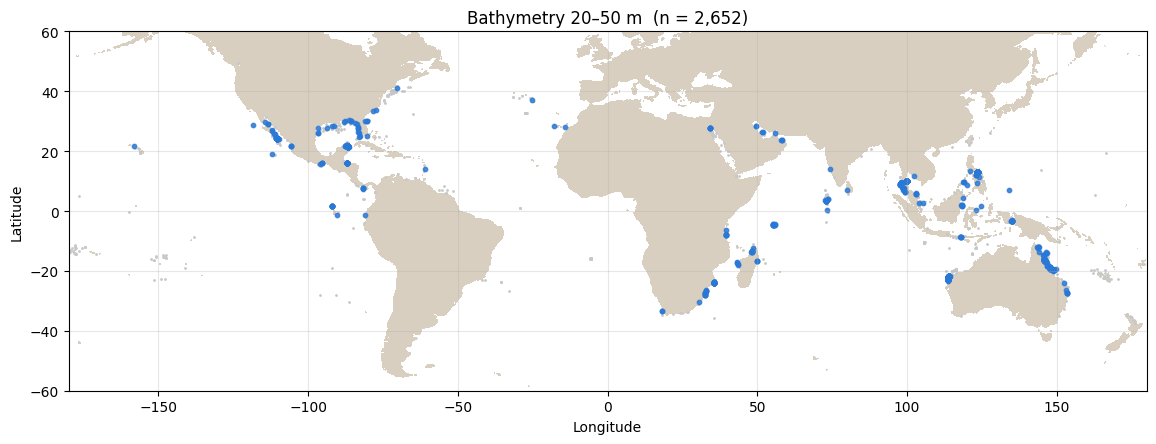

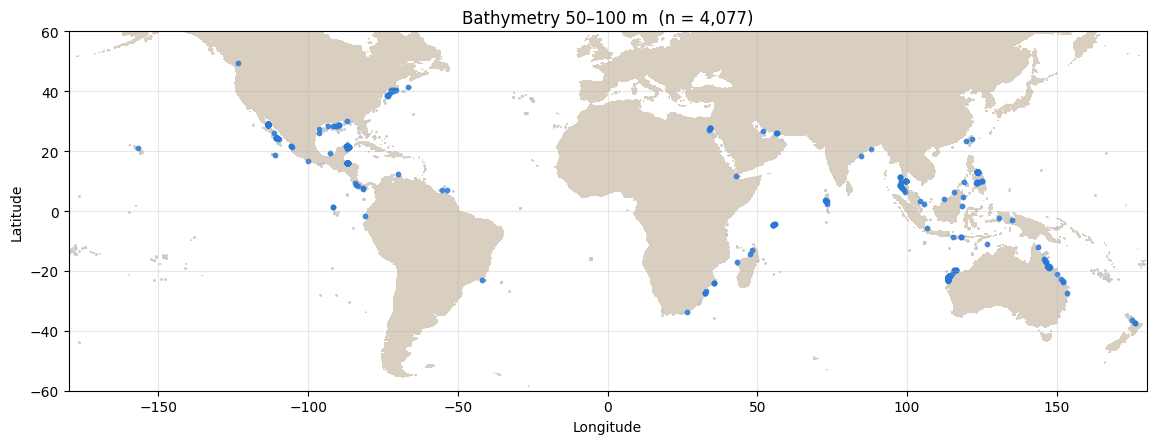

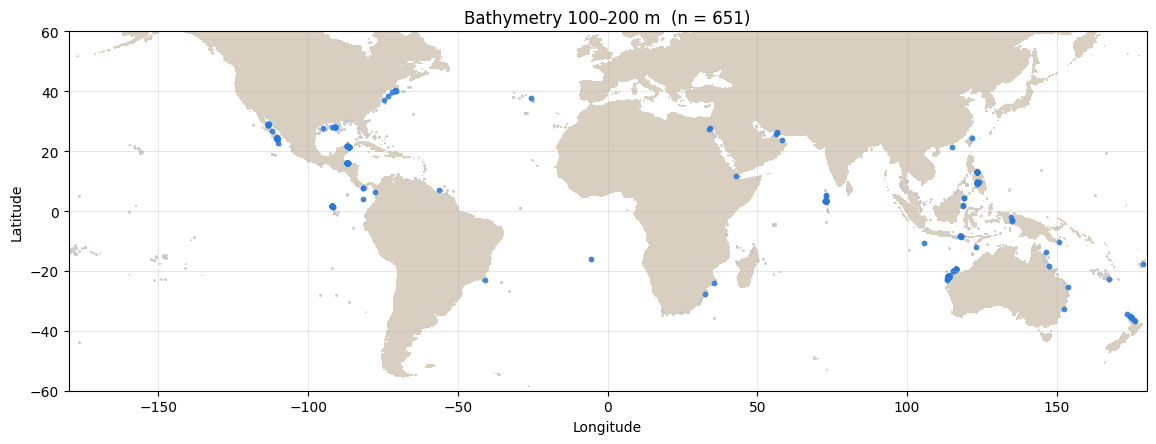

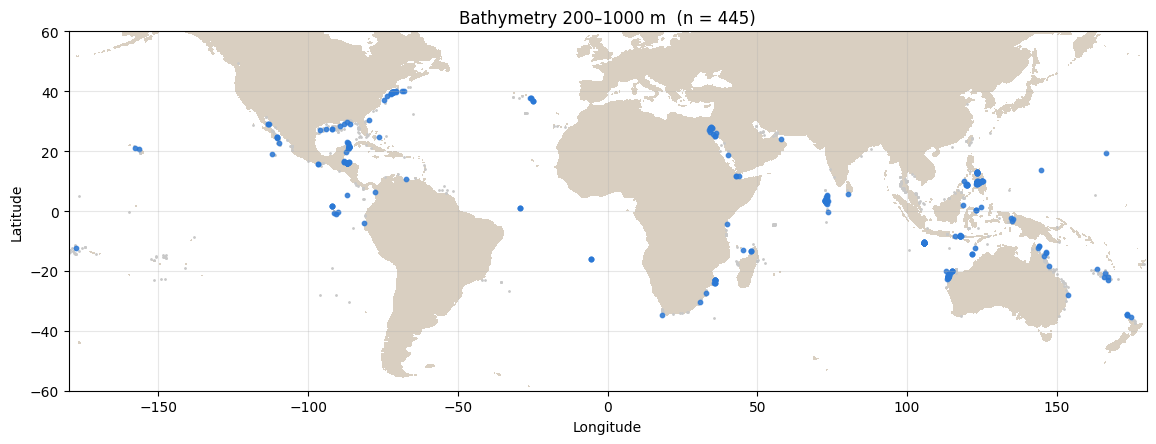

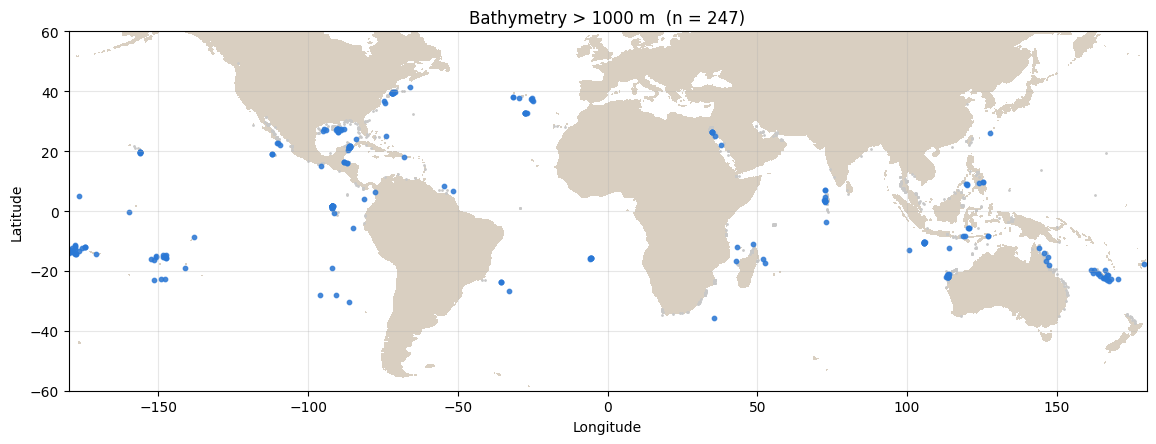

In [45]:
for cl in db['bathymetry_class'].cat.categories:
    map_builder(db[db['bathymetry_class'] == cl], f"Bathymetry {cl} m")

### 5) Chlorophyl maps

Classes chosen from the distribution of `chl_cmems` so that every map has enough points. Records without a value are not shown.

In [46]:
print(db['chl_cmems'].describe().round(2))
db['chl_cmems_class'] = pd.cut(db['chl_cmems'], bins=[0, 0.1, 0.2, 0.3, 0.5, 1, 2, 999], labels=["< 0.1", "0.1–0.2", "0.2–0.3", "0.3–0.5", "0.5–1", "1–2", "> 2"])
db['chl_cmems_class'].value_counts().sort_index()

count    9199.00
mean        0.51
std         0.67
min         0.02
25%         0.25
50%         0.38
75%         0.57
max        17.92
Name: chl_cmems, dtype: float64


,count
chl_cmems_class,
< 0.1,257
0.1–0.2,1391
0.2–0.3,1611
0.3–0.5,3071
0.5–1,2199
1–2,496
> 2,174


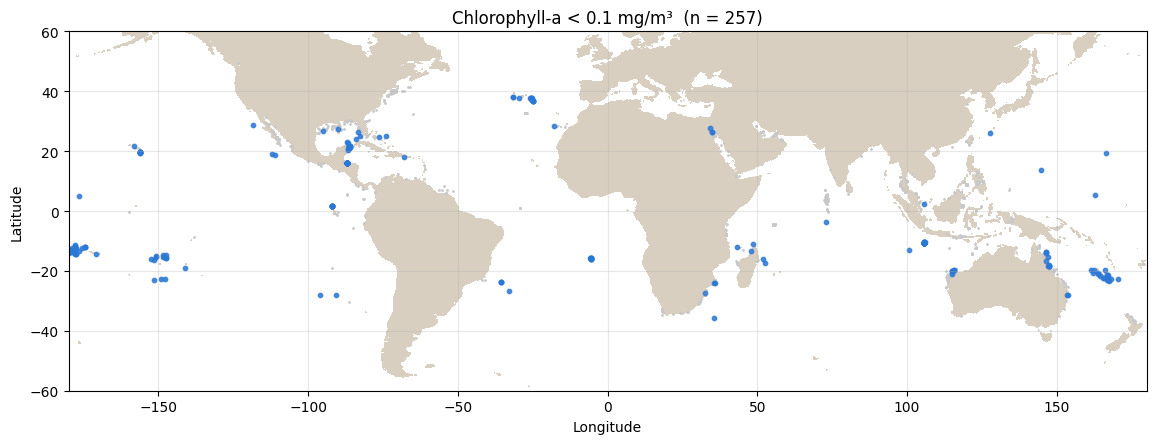

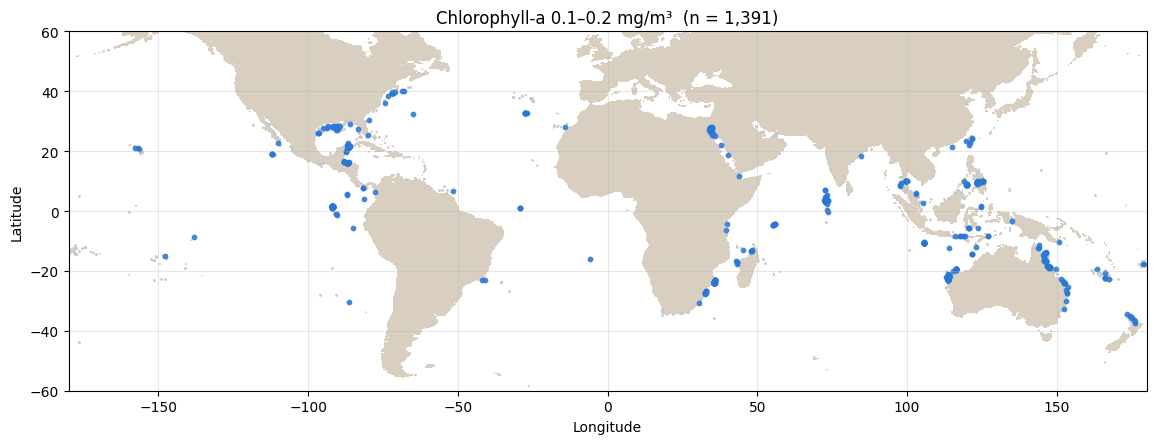

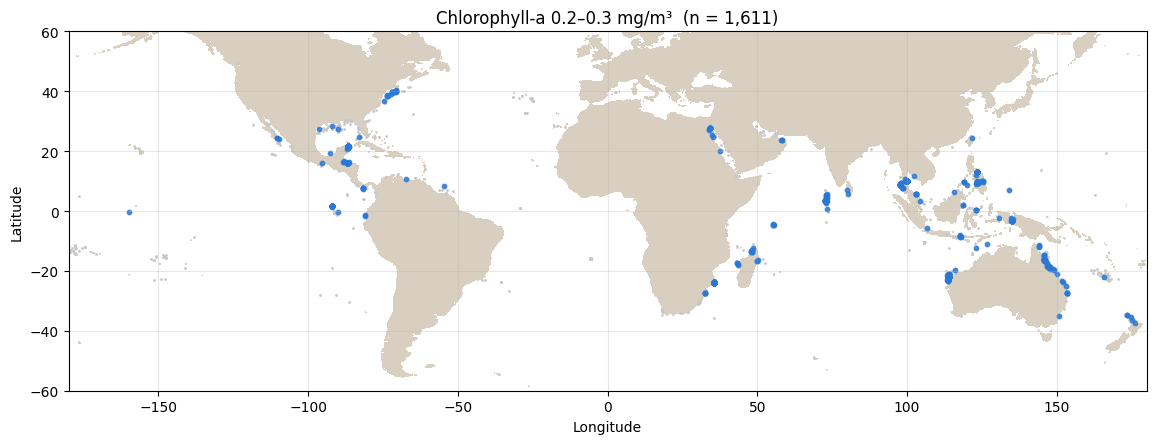

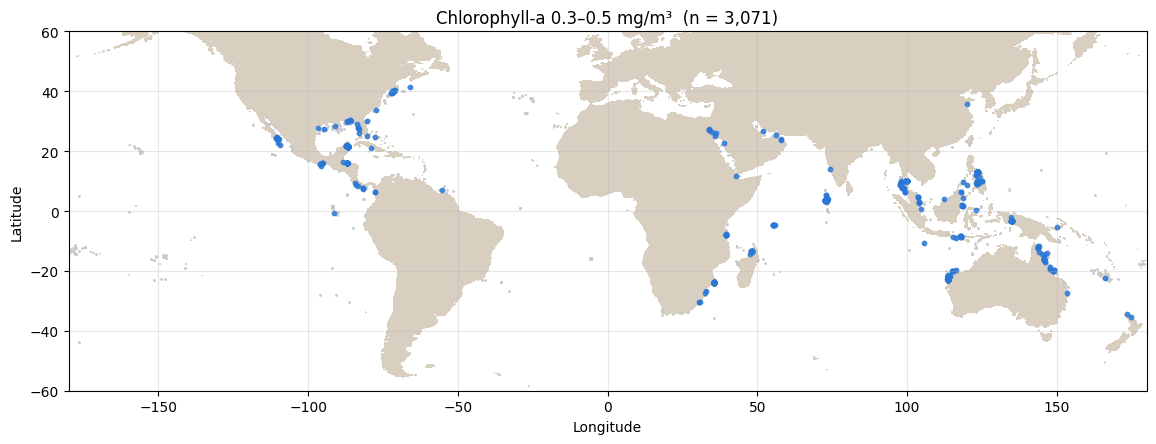

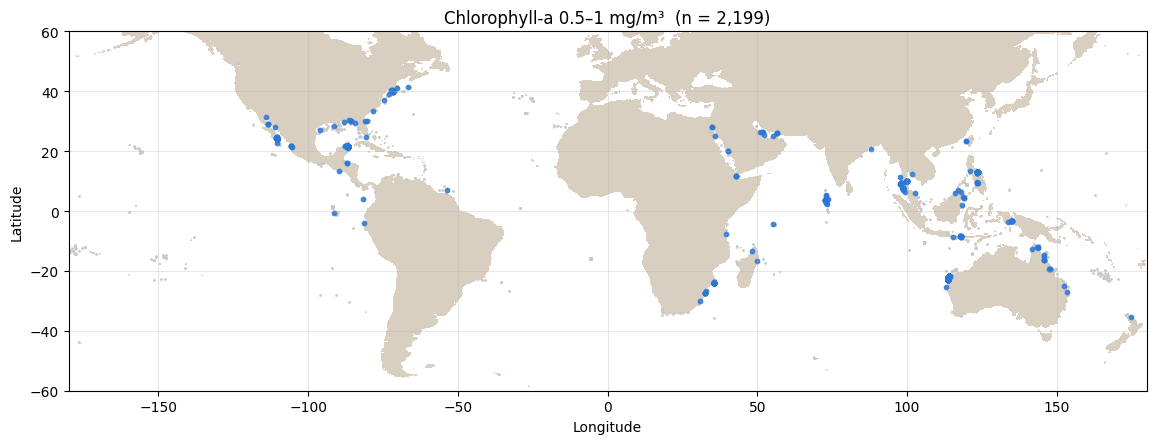

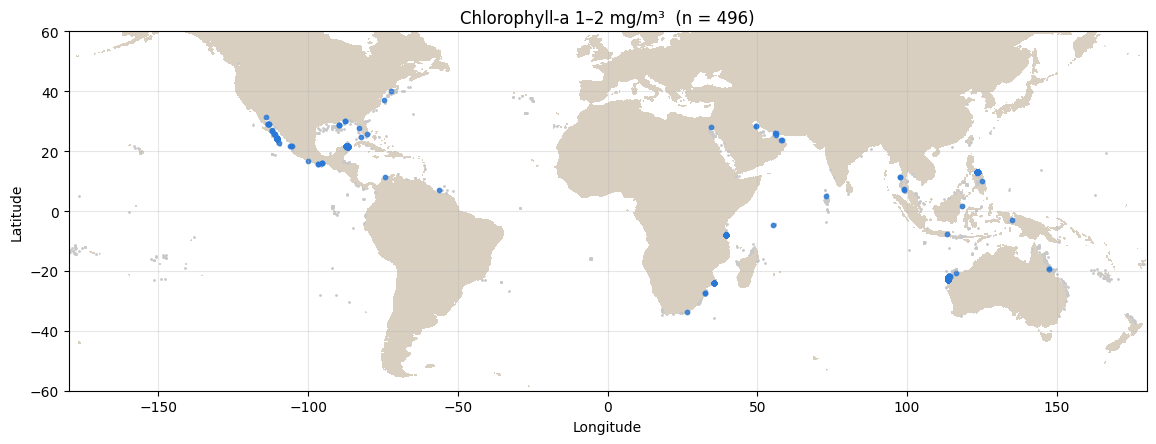

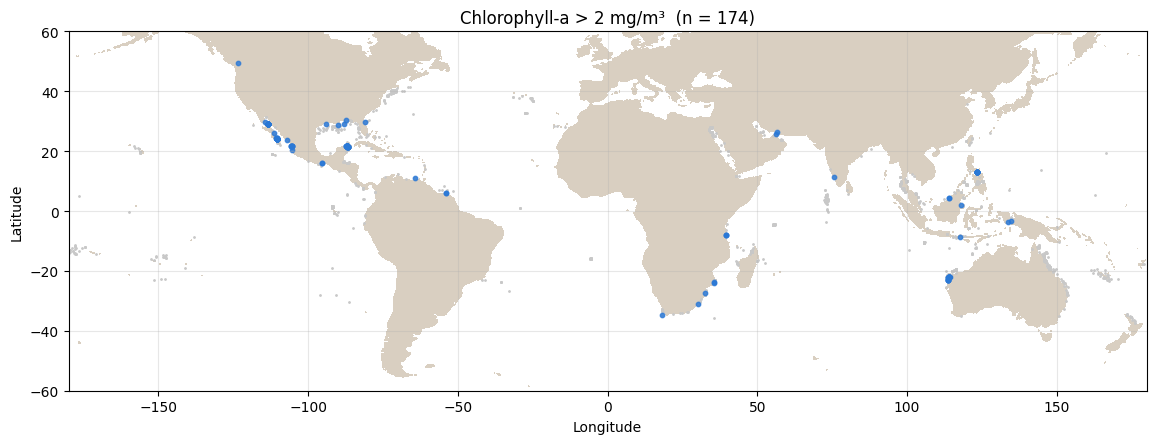

In [47]:
for cl in db['chl_cmems_class'].cat.categories:
    map_builder(db[db['chl_cmems_class'] == cl], f"Chlorophyll-a {cl} mg/m³")

### 6) Salinity maps

Classes chosen from the distribution of `sss_cmems` so that every map has enough points. Records without a value are not shown.

In [48]:
print(db['sss_cmems'].describe().round(2))
db['sss_cmems_class'] = pd.cut(db['sss_cmems'], bins=[0, 33, 34, 35, 36, 37, 99], labels=["< 33", "33–34", "34–35", "35–36", "36–37", "> 37"])
db['sss_cmems_class'].value_counts().sort_index()

count    9264.00
mean       34.51
std         1.07
min        22.80
25%        34.07
50%        34.45
75%        34.98
max        39.77
Name: sss_cmems, dtype: float64


,count
sss_cmems_class,
< 33,444
33–34,1486
34–35,5076
35–36,1387
36–37,800
> 37,71


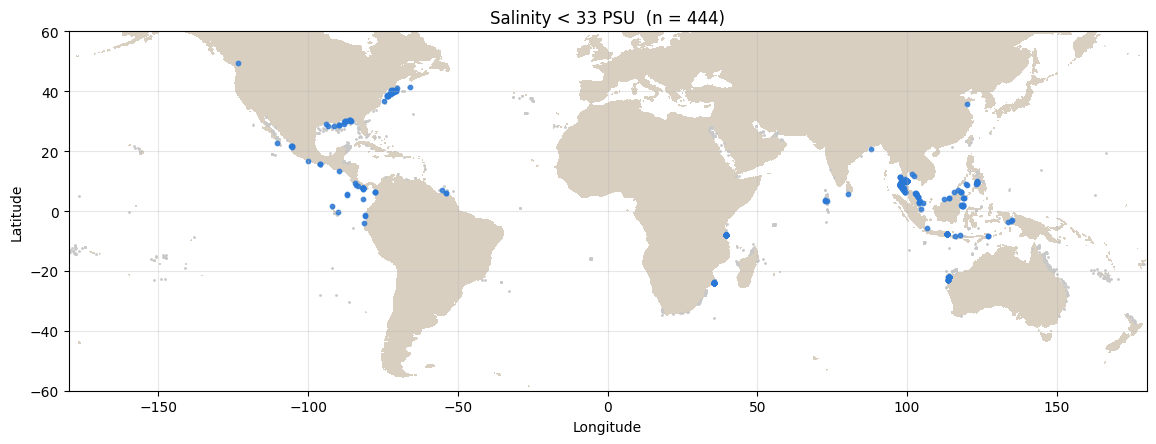

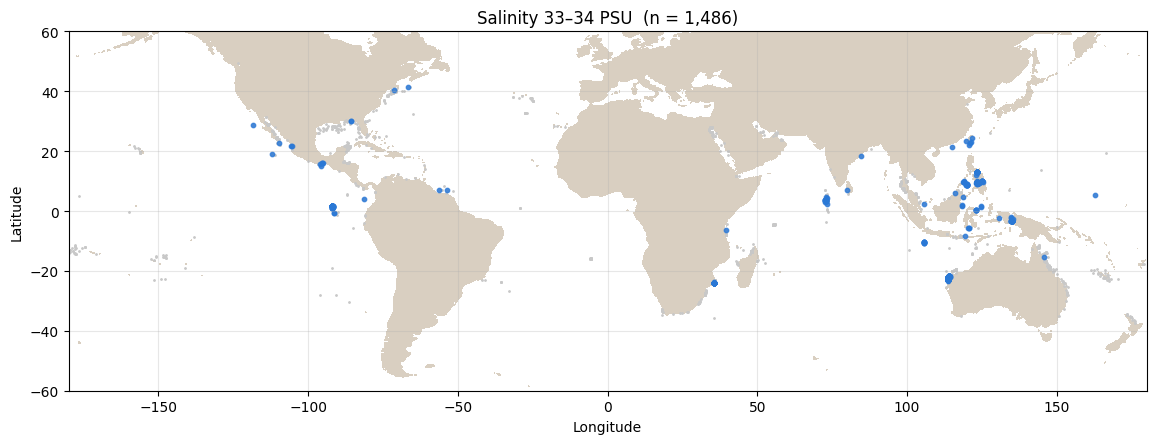

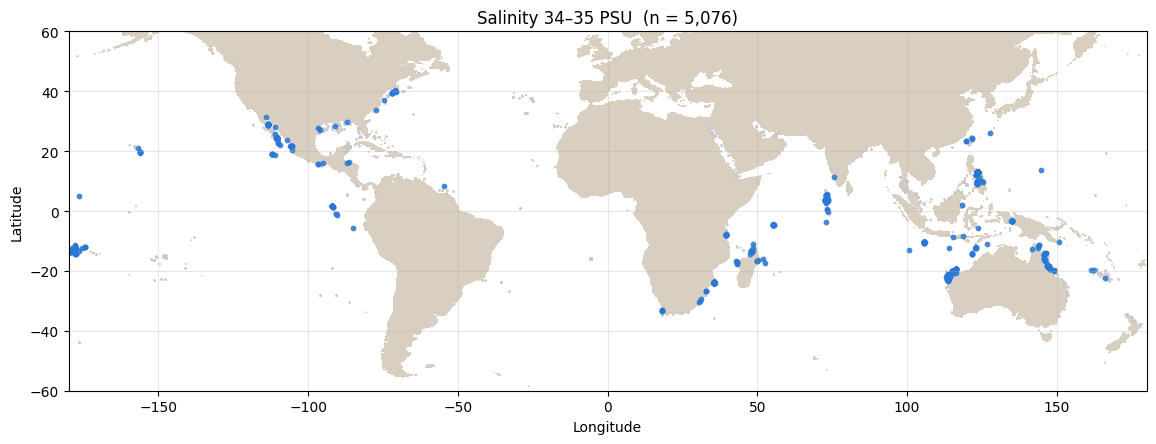

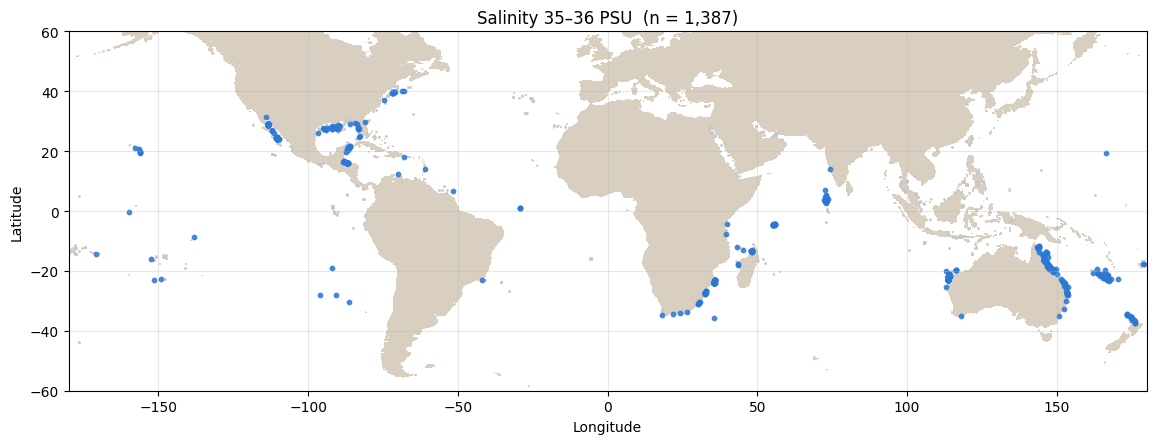

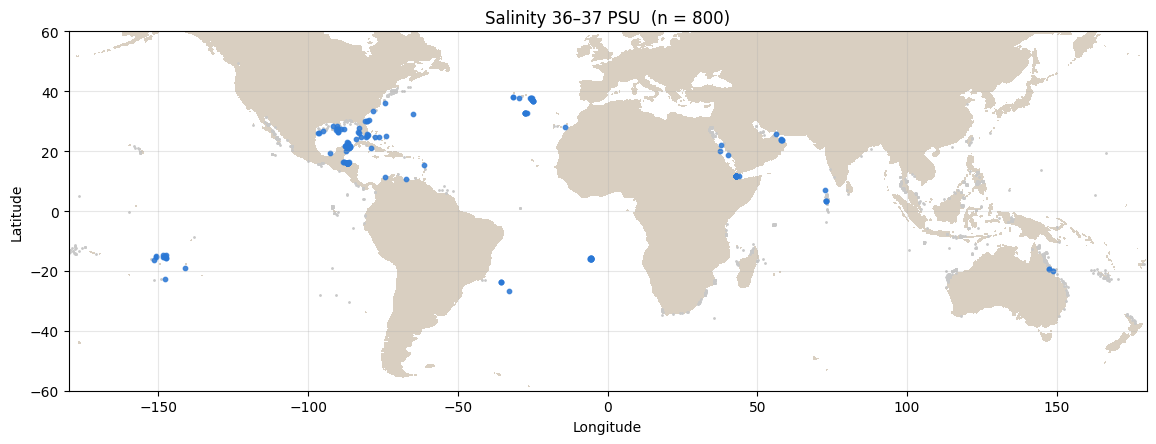

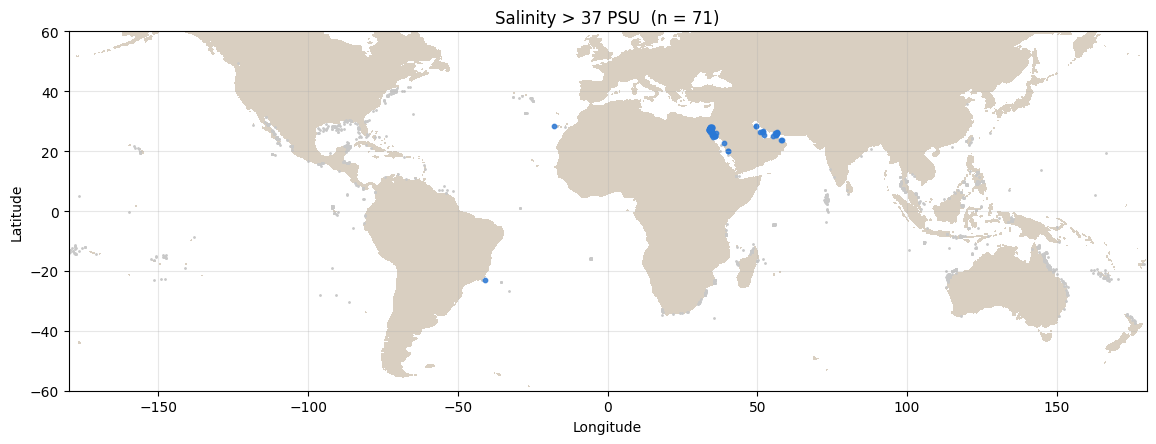

In [49]:
for cl in db['sss_cmems_class'].cat.categories:
    map_builder(db[db['sss_cmems_class'] == cl], f"Salinity {cl} PSU")

### 7) Distance to Shore maps

Classes chosen from the distribution of `shoredistance` so that every map has enough points. Records without a value are not shown.

In [50]:
print(db['shoredistance'].describe().round(2))
db['shoredistance_class'] = pd.cut(db['shoredistance'], bins=[-1e9, 0, 500, 1000, 2000, 5000, 10000, 20000, 1e9], labels=["on land (< 0)", "0–500 m", "500 m–1 km", "1–2 km", "2–5 km", "5–10 km", "10–20 km", "> 20 km"])
db['shoredistance_class'].value_counts().sort_index()

count       9731.00
mean        9853.38
std        37296.94
min         -975.00
25%          585.00
50%         5065.00
75%         7200.00
max      1461665.00
Name: shoredistance, dtype: float64


,count
shoredistance_class,
on land (< 0),48
0–500 m,2165
500 m–1 km,1039
1–2 km,731
2–5 km,877
5–10 km,3125
10–20 km,1184
> 20 km,562


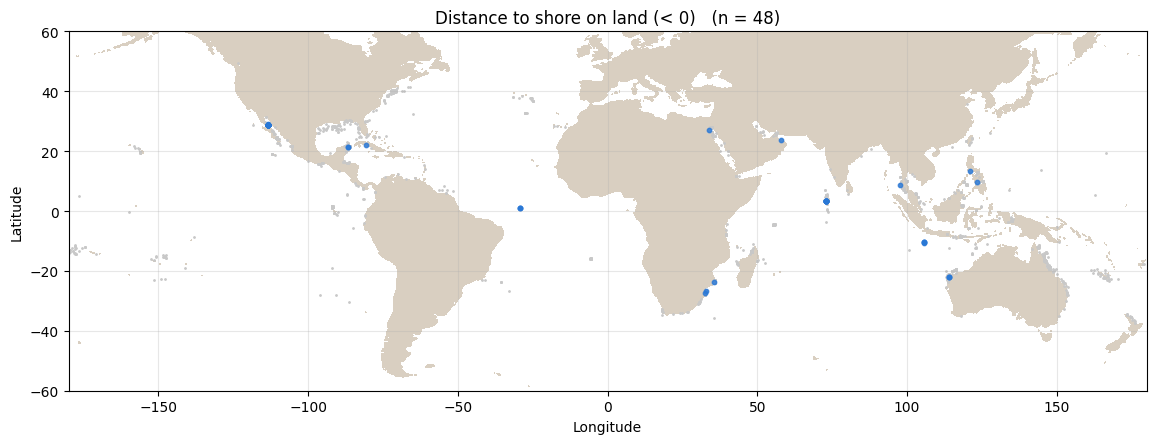

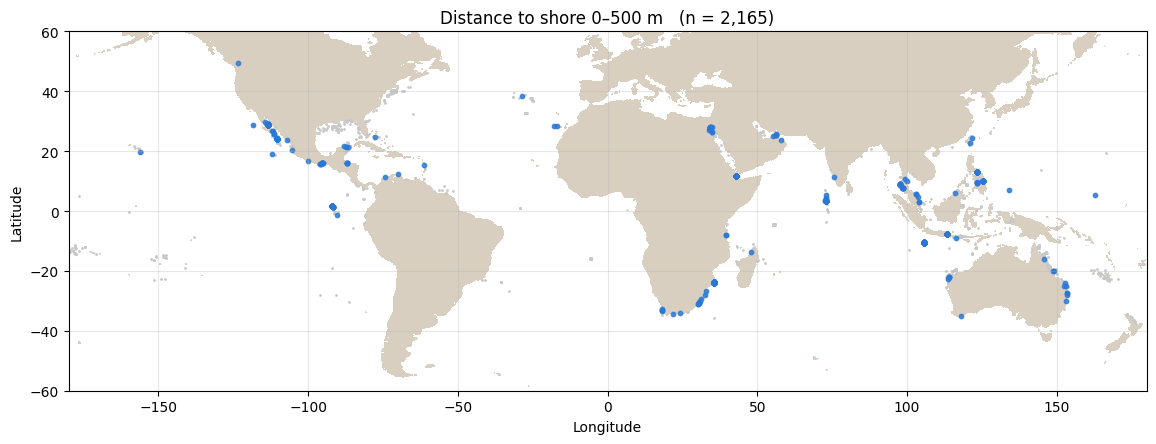

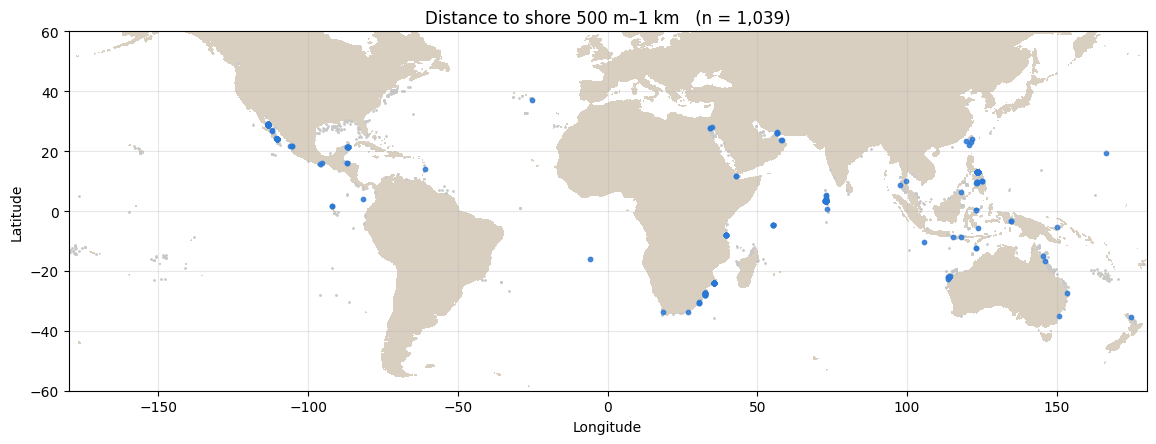

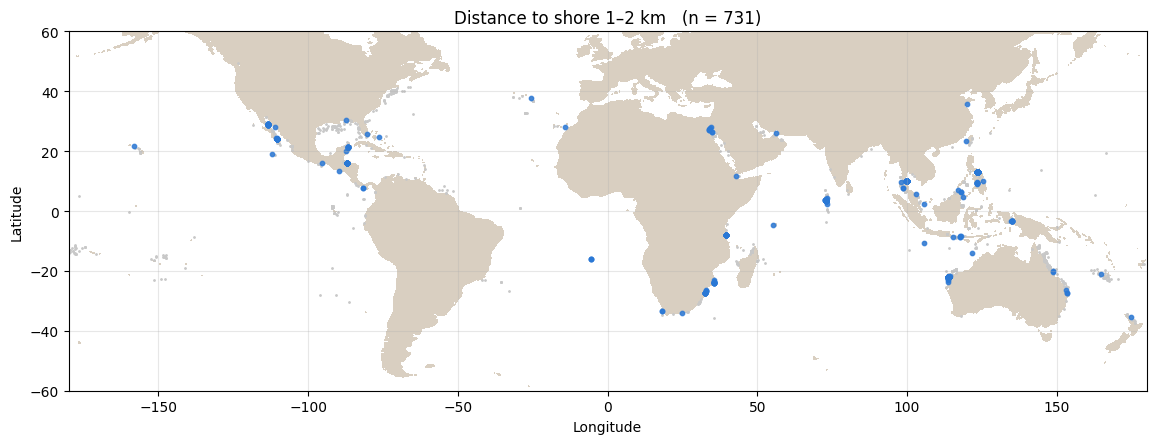

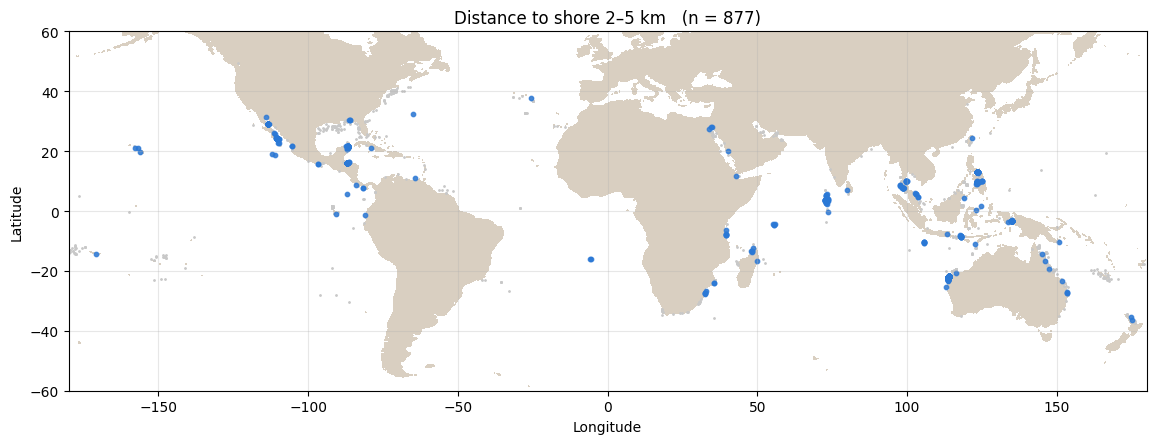

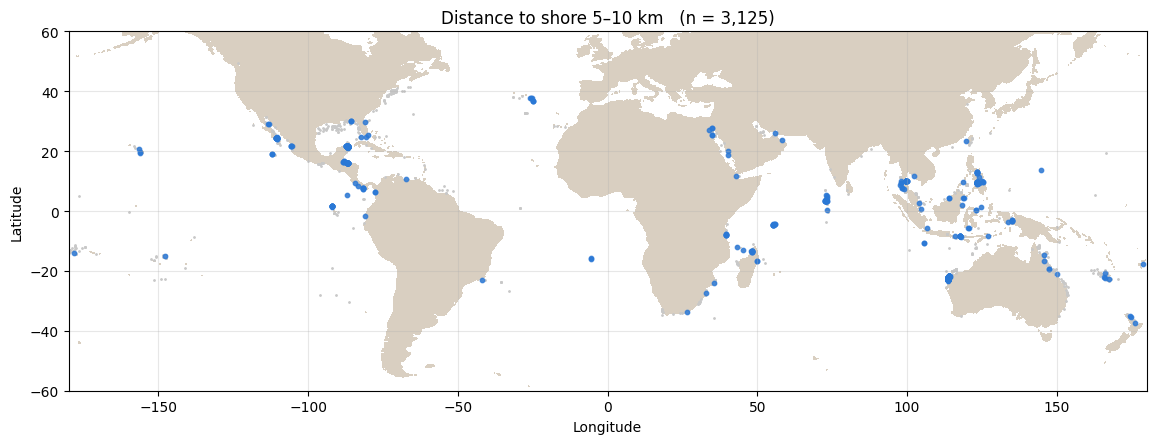

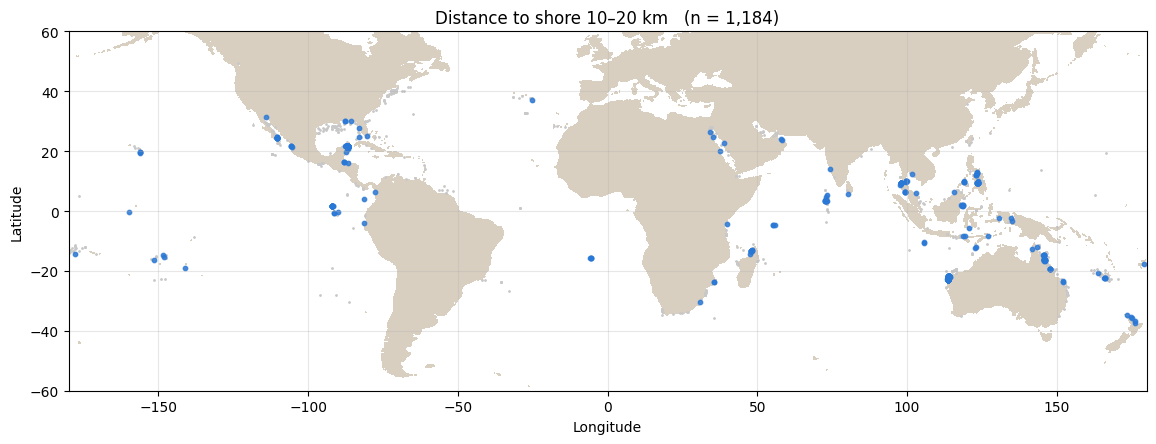

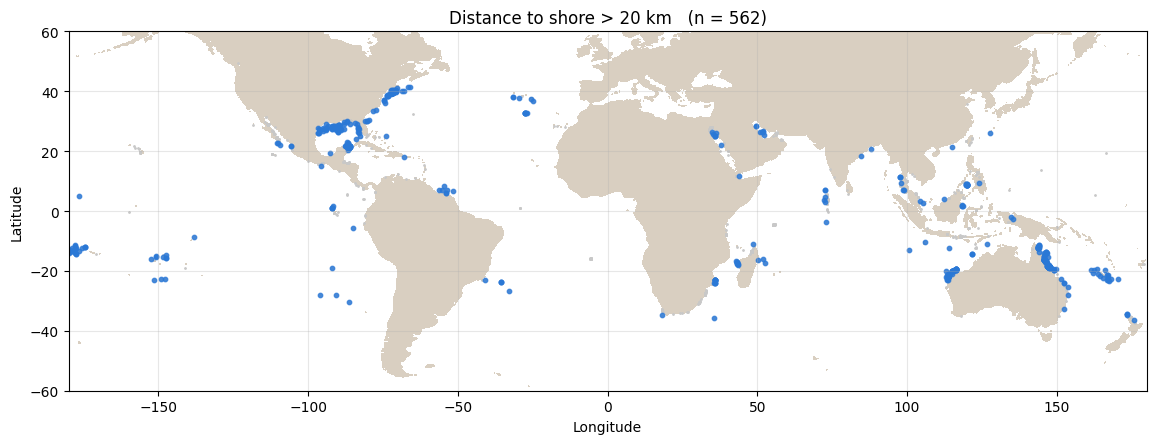

In [51]:
for cl in db['shoredistance_class'].cat.categories:
    map_builder(db[db['shoredistance_class'] == cl], f"Distance to shore {cl} ")